In [107]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [26]:
# Reaad the csv files - Global Health Statistics
df = pd.read_csv("/content/hotel_bookings.csv")

In [27]:
# Get first 5 rows using head
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [28]:
# Get last 5 row of Dataset using Tail
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [29]:
# Checking the info of the given Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### **Description:**

The dataset contains float64, int64, object

There are total 32 features in the given data



In [30]:
# Checking the Description of the given Dataset
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [31]:
# Shape of the Dataset
df.shape

(119390, 32)

In [32]:
# Columns in the Dataset
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [33]:
# Check the missing Values
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [34]:
# Checking Unique Values
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [35]:
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

# **Data Cleaning**

In [36]:
# Checking The duplicate Rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 31994


In [37]:
# Checking the values of missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 129425


In [38]:
# Removeing the duplicate rows
print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))
print("Duplicates remaining:", df.duplicated().sum())

Rows before removing duplicates: 119390
Rows after removing duplicates: 87396
Duplicates remaining: 0


In [39]:
# Find  the missing values
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing Count", ascending=False)
)

,Missing Count,Missing Percentage
company,82137,93.982562
agent,12193,13.951439
country,452,0.517186
children,4,0.004577


In [40]:
# Handle missing values

df["company"] = df["company"].fillna(0)
df["agent"] = df["agent"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["children"] = df["children"].fillna(0)

print("Missing values after treatment:")

missing_after = df.isnull().sum()
display(missing_after[missing_after > 0])

Missing values after treatment:


,0


In [41]:
# Verifying the data cleaning with respect to data
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Dataset shape: (87396, 32)
Total missing values: 0
Total duplicate rows: 0


In [42]:
# Original Column names
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [43]:
# Standardize Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "percent", regex=False)
)

print("Updated Column Names:")
print(df.columns.tolist())

Updated Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [44]:
# Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

In [45]:
numerical_cols

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [46]:
# Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [47]:
categorical_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

### **Numerical Distribution Analysis**

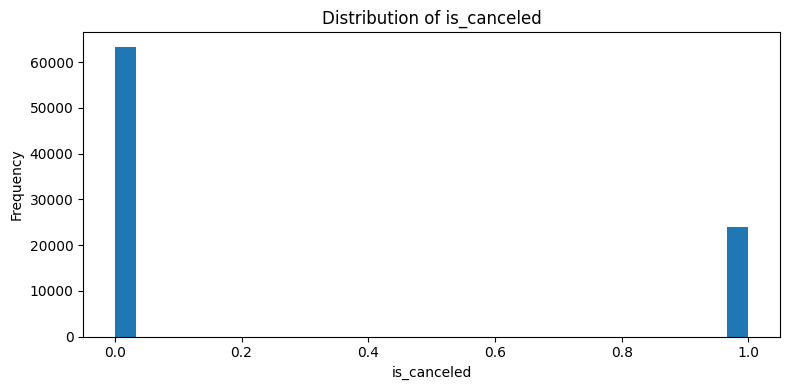

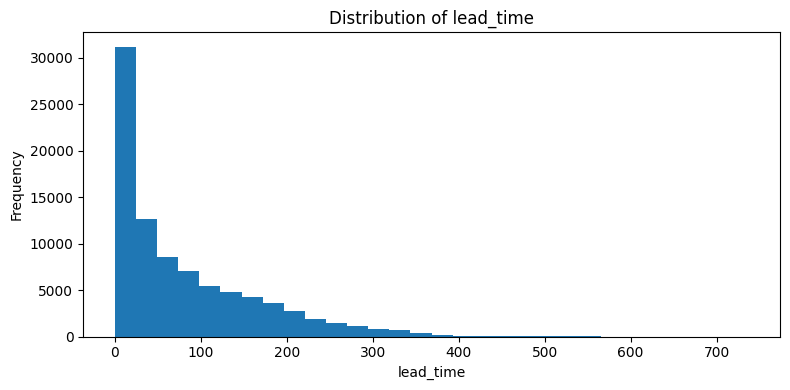

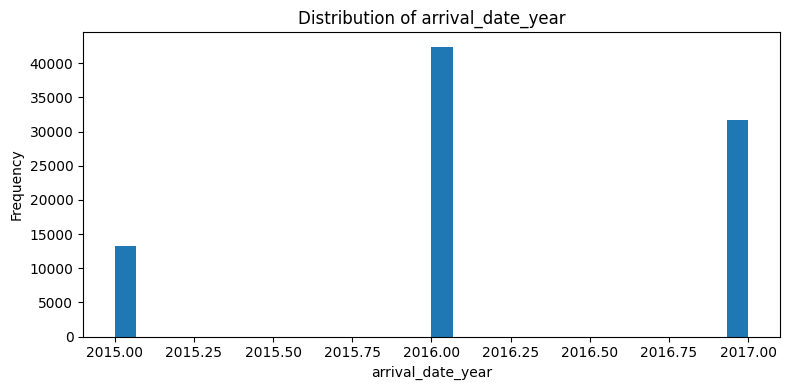

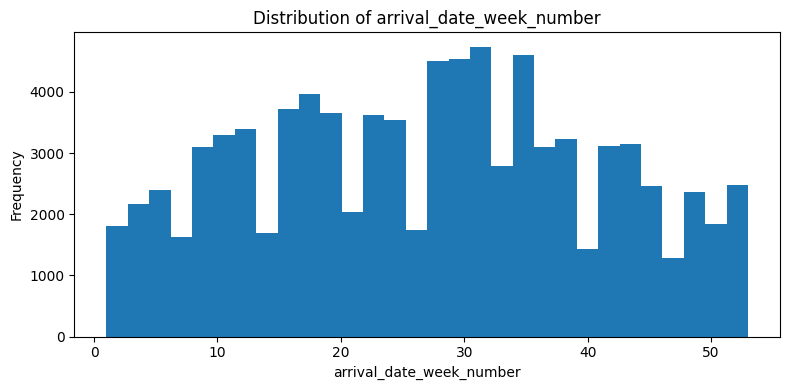

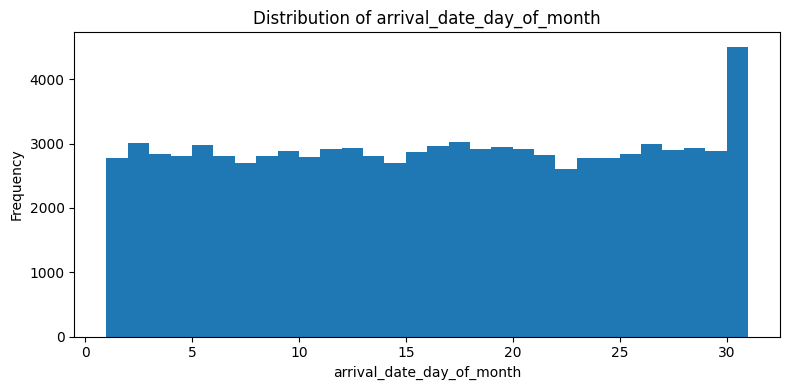

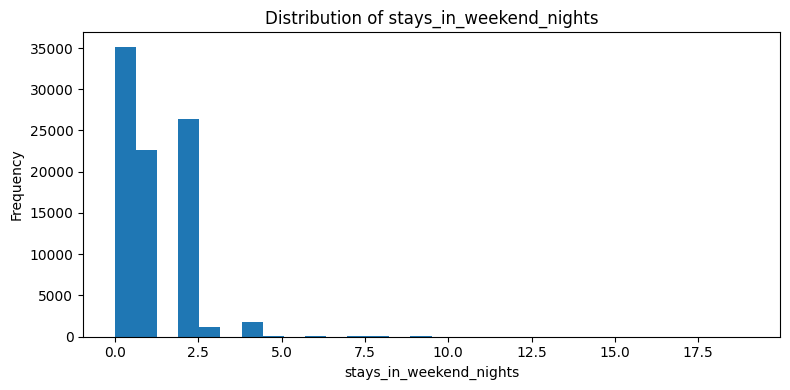

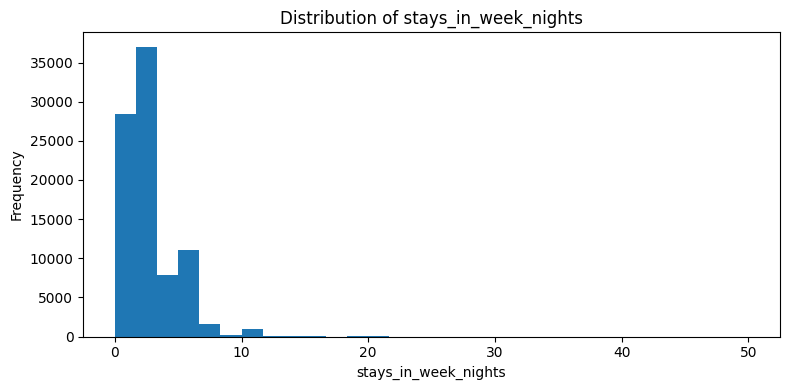

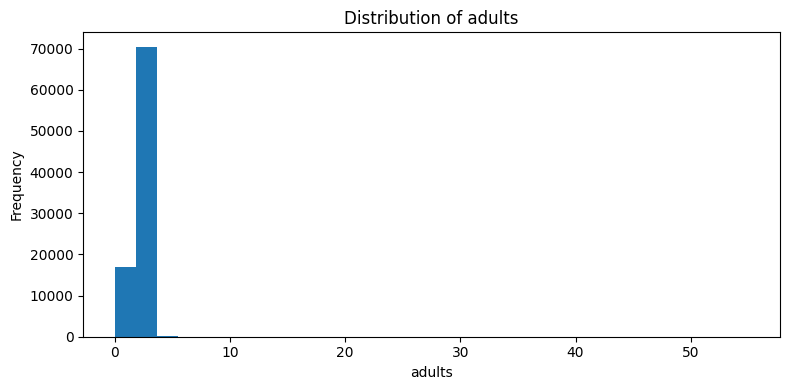

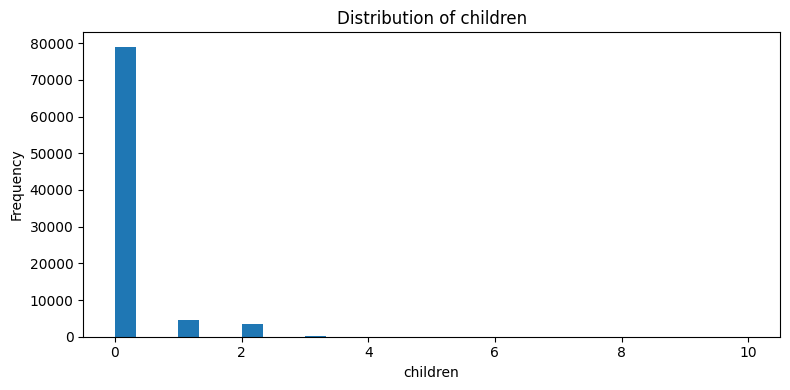

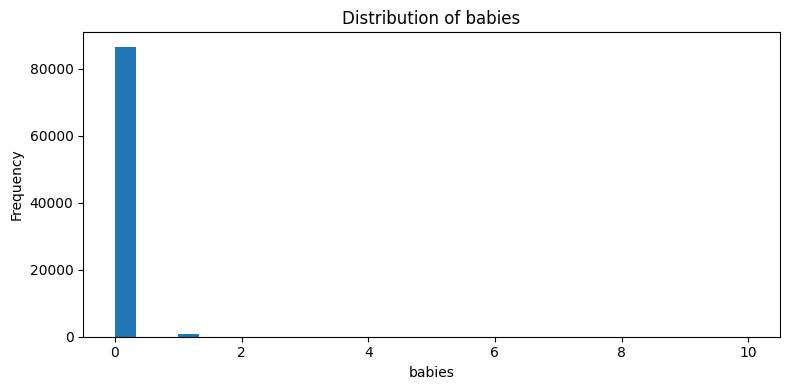

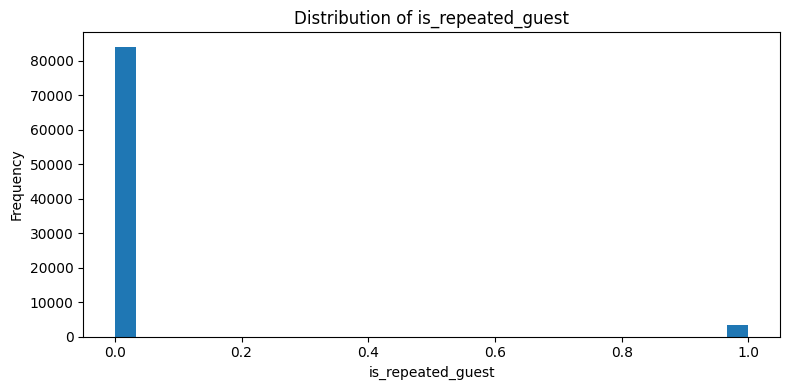

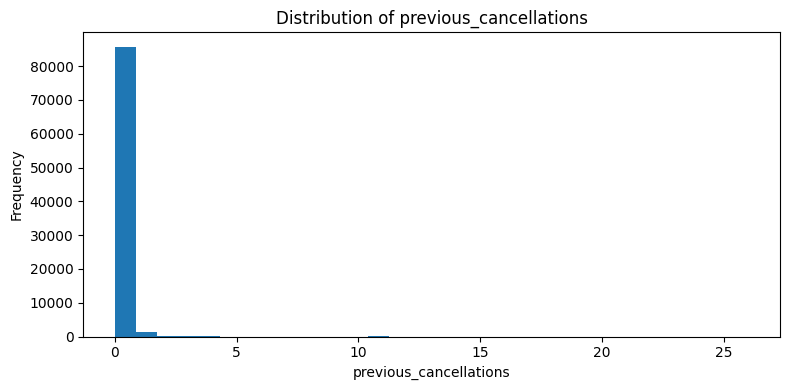

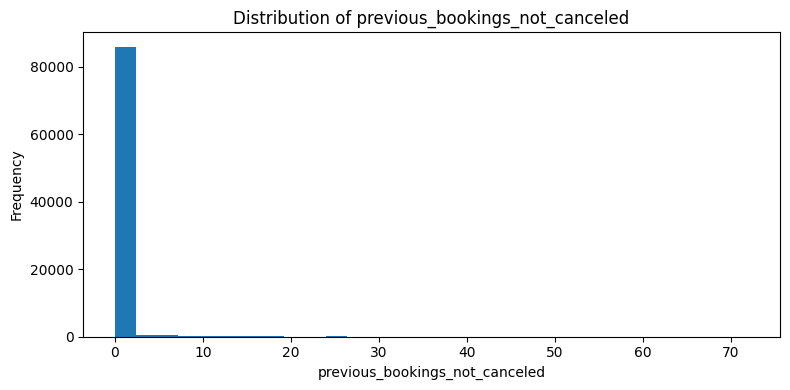

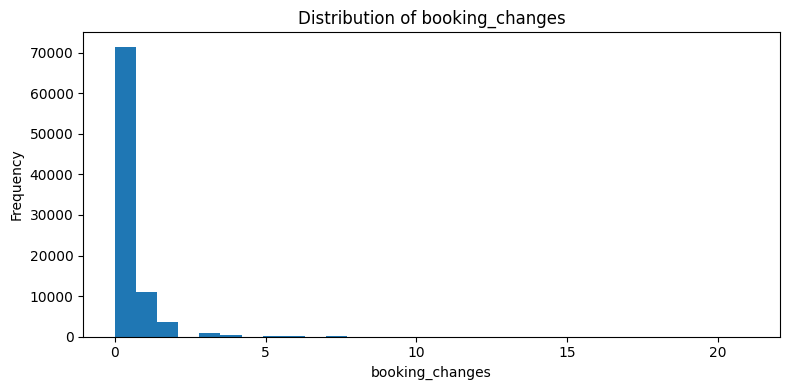

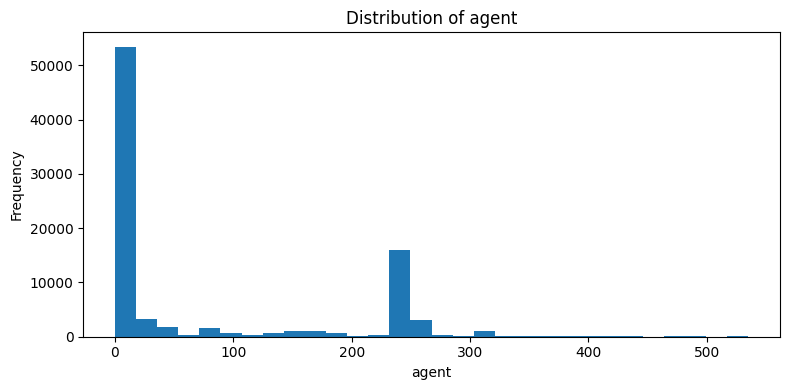

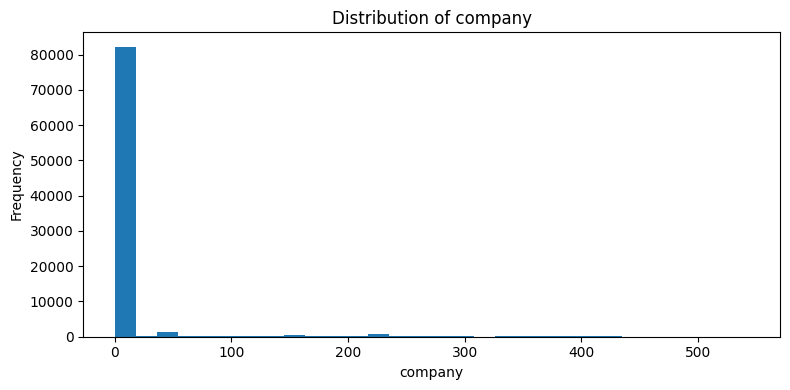

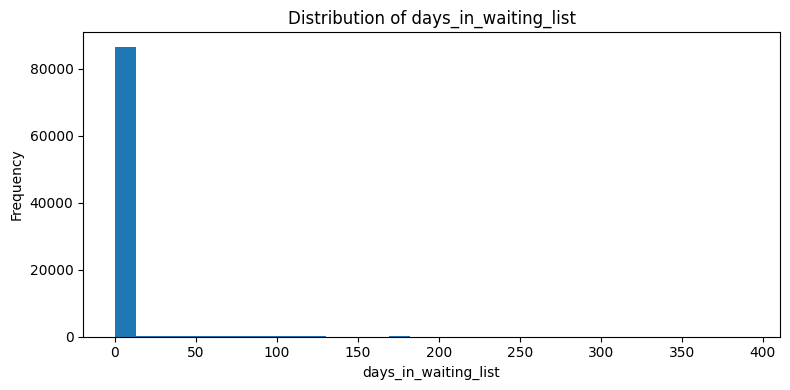

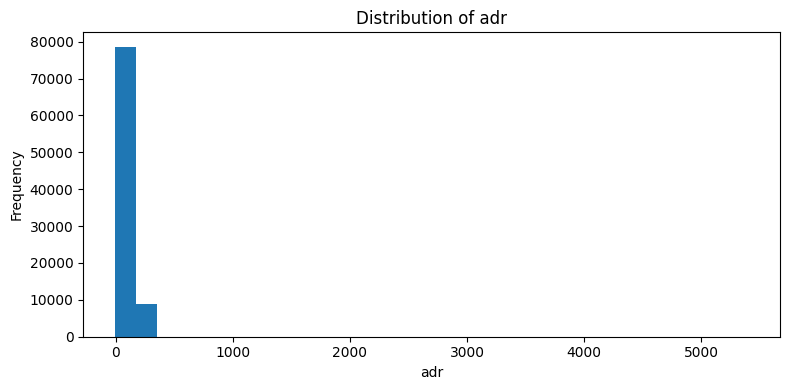

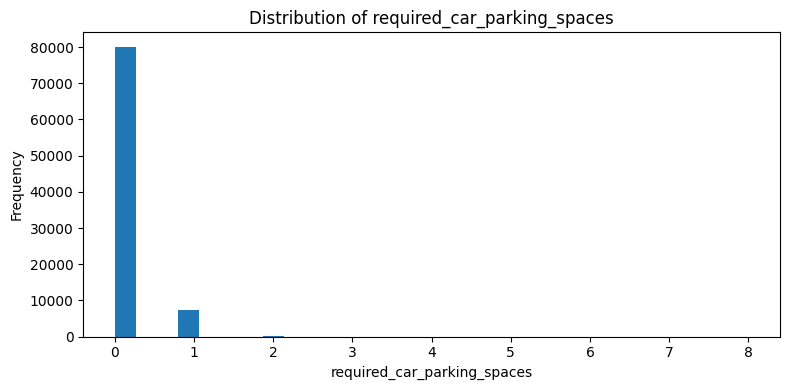

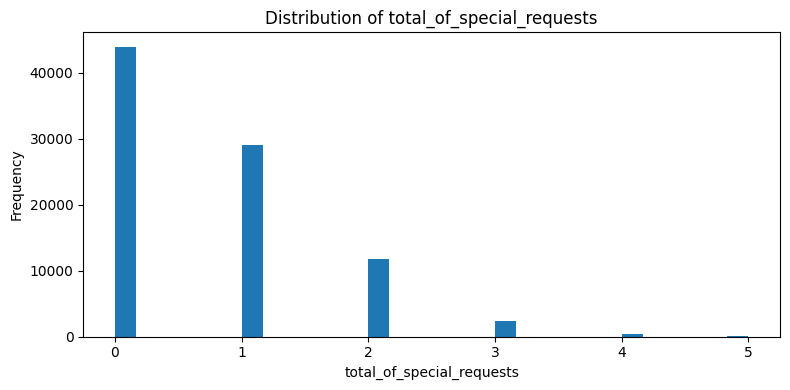

In [48]:
# Plot visual for the Numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [49]:
# The summarization of numerical in dataframe
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87396.0,0.274898,0.446466,0.00,0.0,0.0,1.0,1.0
lead_time,87396.0,79.891368,86.052325,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87396.0,2016.210296,0.686102,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87396.0,26.838334,13.674572,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87396.0,15.815541,8.835146,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87396.0,1.005263,1.031921,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87396.0,2.625395,2.053584,0.00,1.0,2.0,4.0,50.0
adults,87396.0,1.875795,0.626500,0.00,2.0,2.0,2.0,55.0
children,87396.0,0.138633,0.455871,0.00,0.0,0.0,0.0,10.0
babies,87396.0,0.010824,0.113597,0.00,0.0,0.0,0.0,10.0


###**Description**

The summarised table gives the detail description about the numerical columns present in the give data set

#### **Categorical Variable Analysis**

In [50]:
# Finding the Unique categoties
for col in categorical_cols:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts())


hotel
Number of unique values: 2
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

arrival_date_month
Number of unique values: 12
arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

meal
Number of unique values: 5
meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

country
Number of unique values: 178
country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64

market_segment
Number of unique values: 8
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complemen

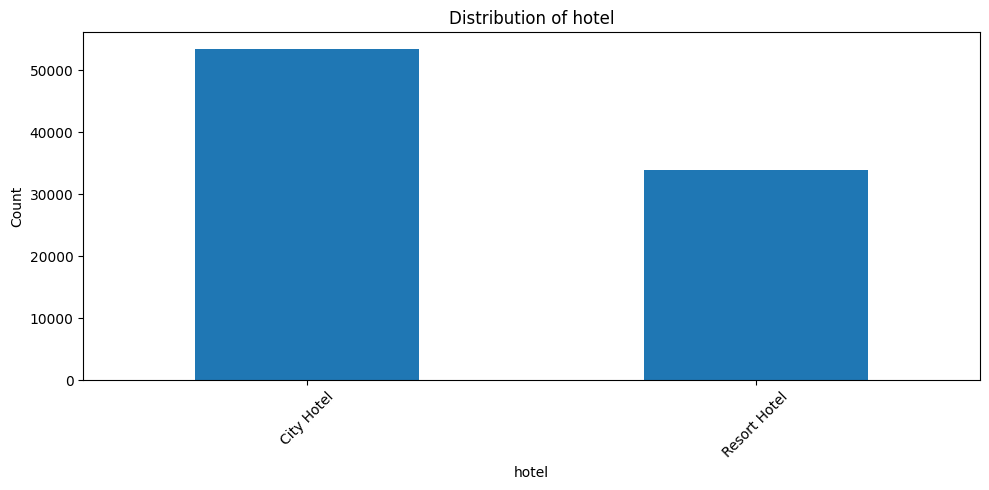

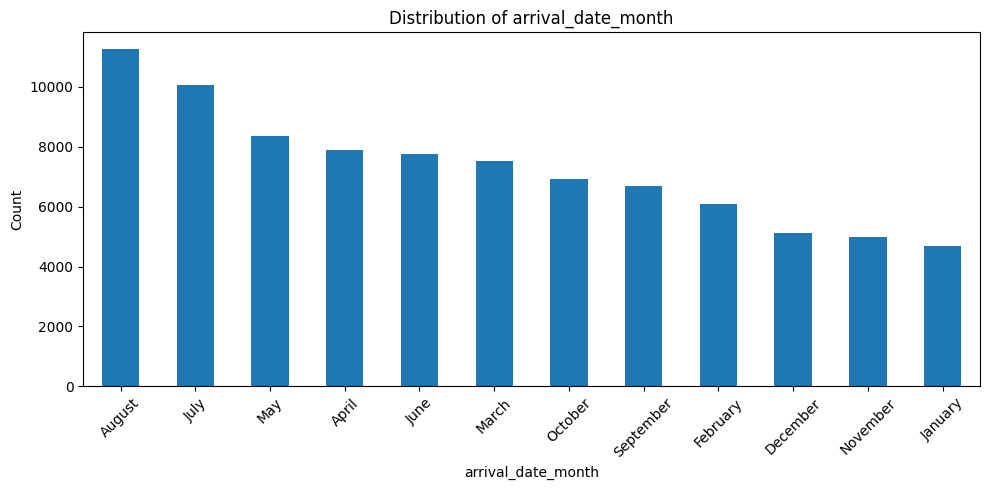

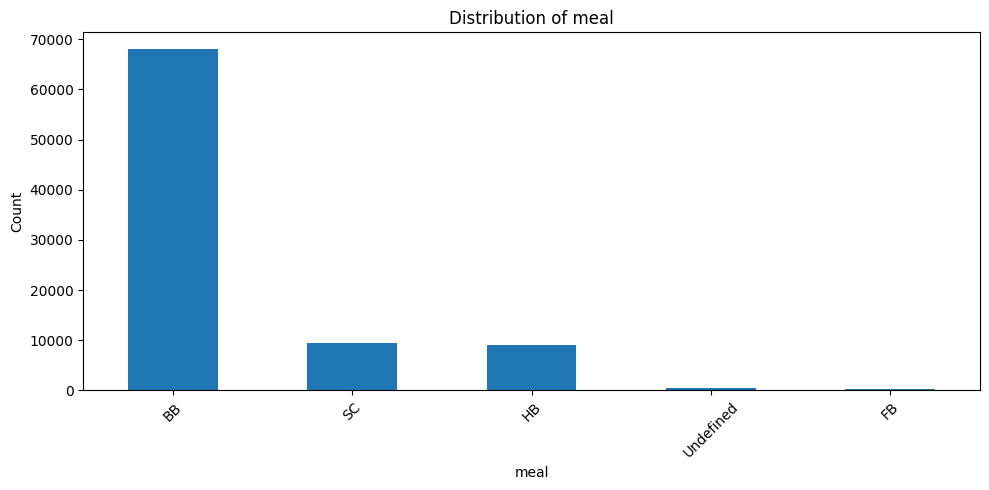

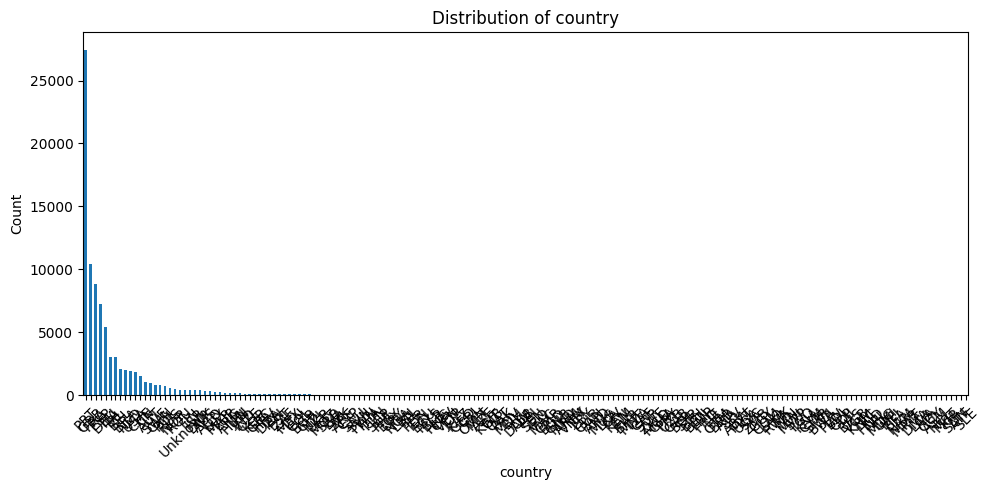

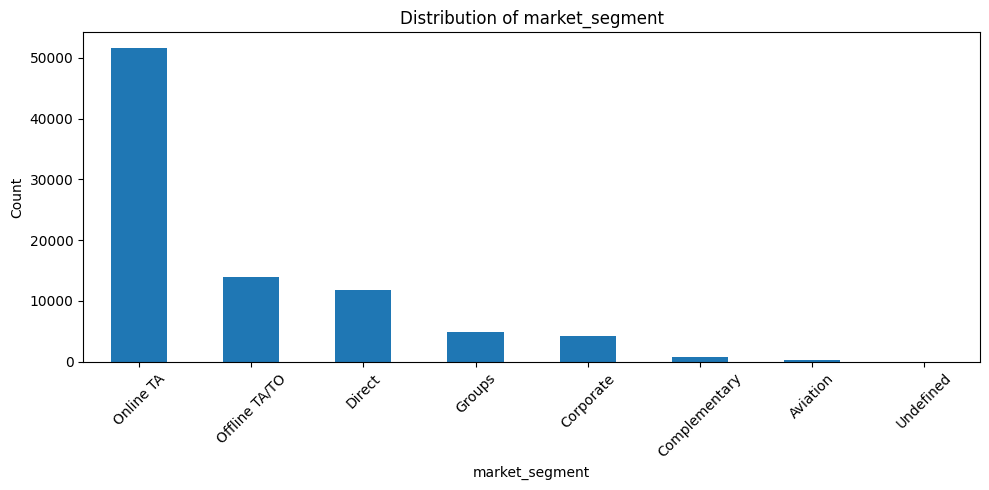

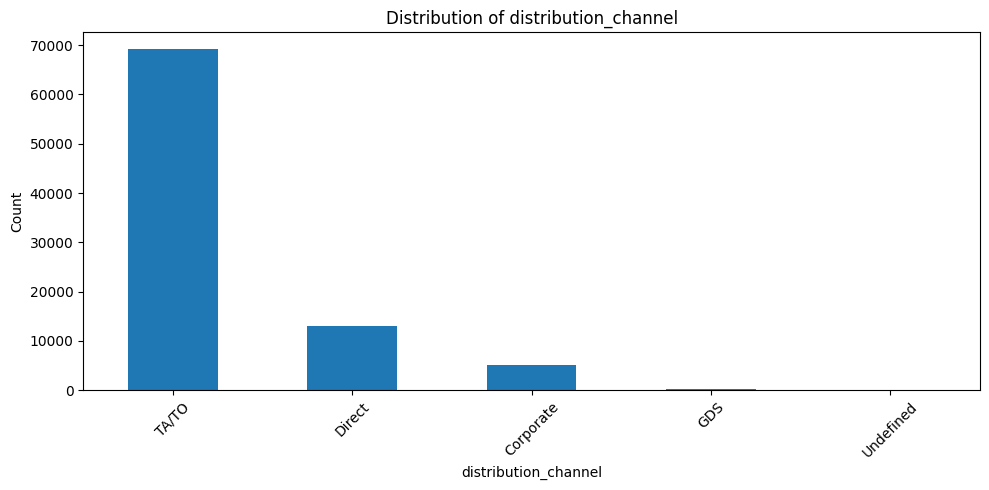

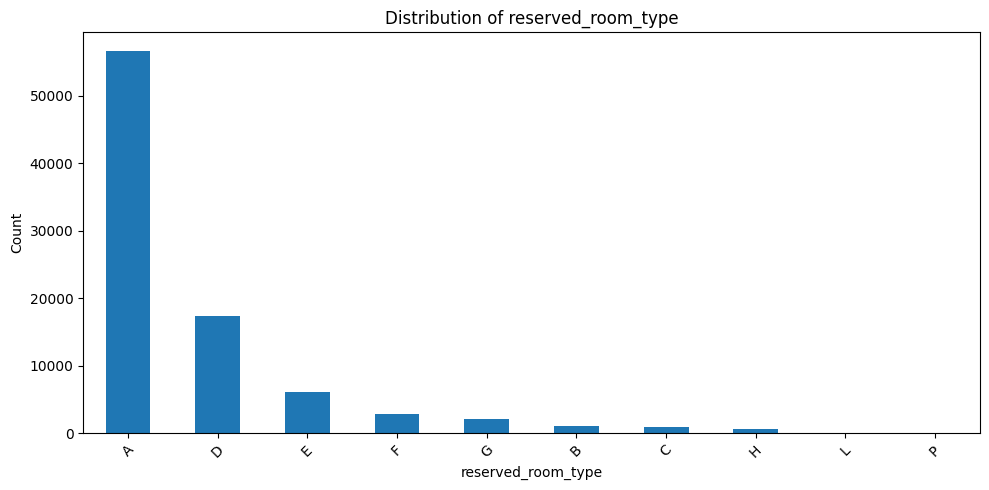

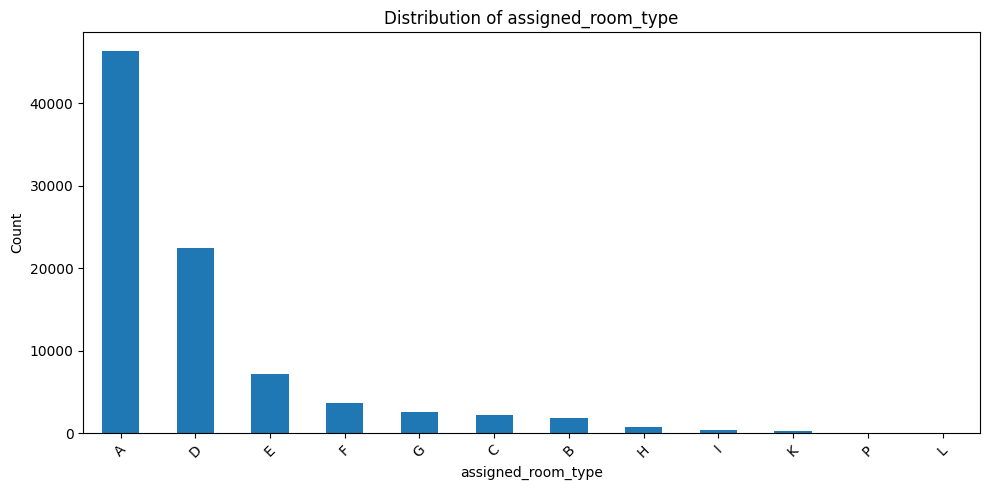

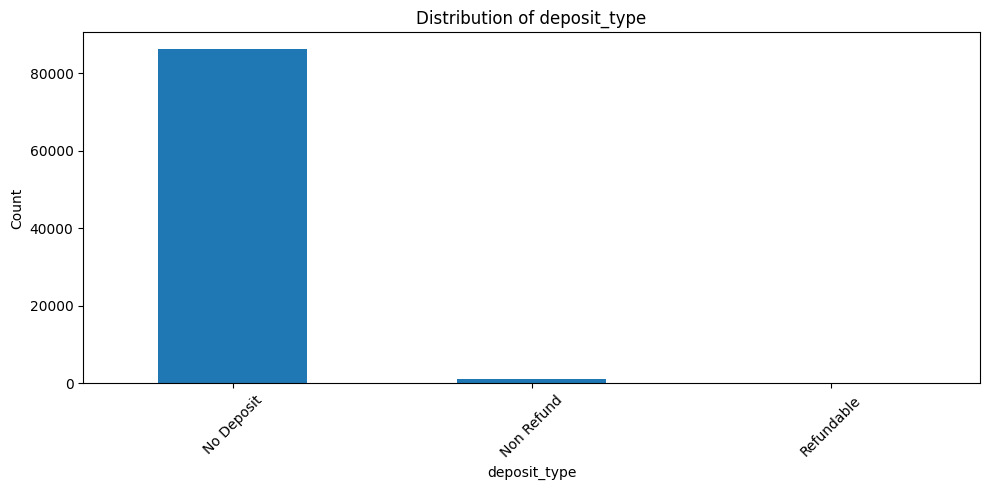

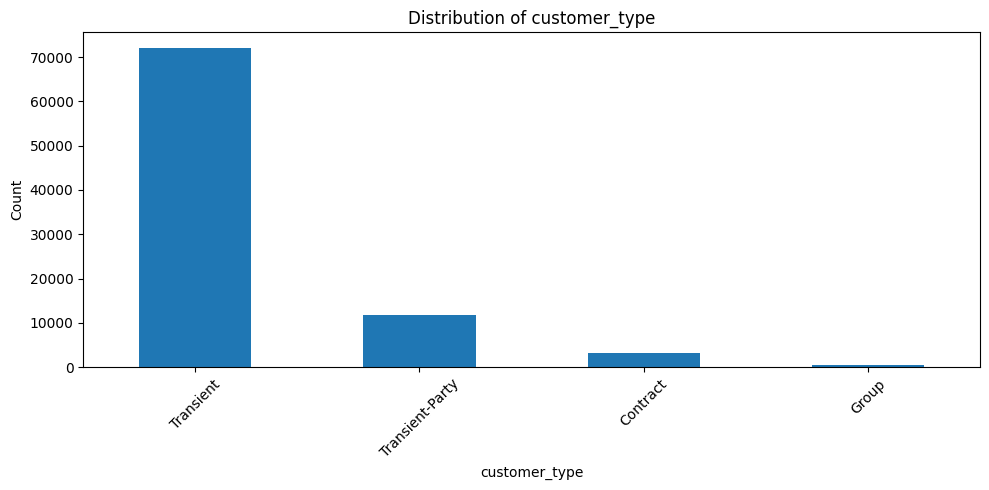

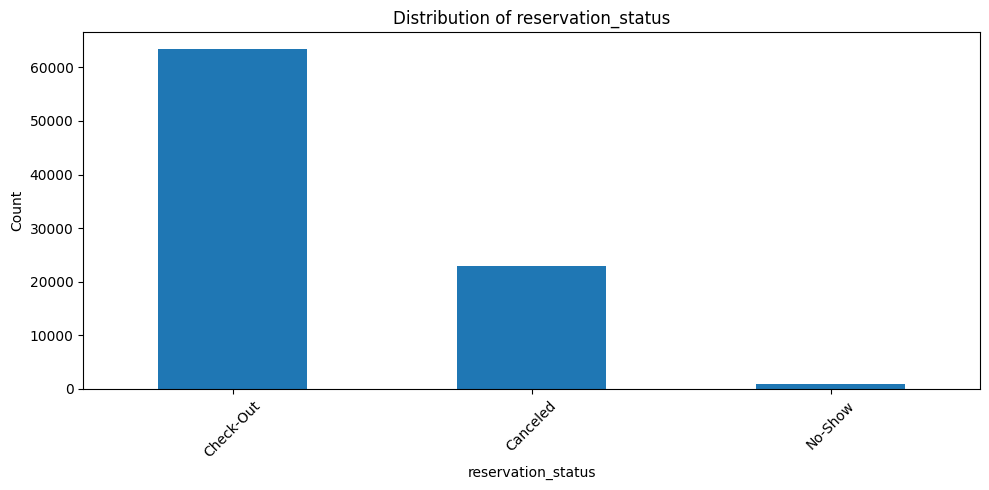

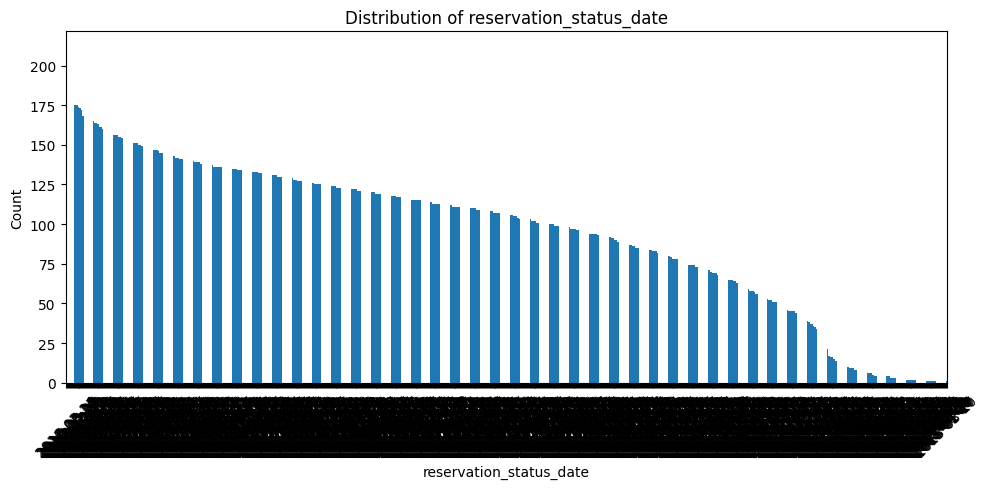

In [51]:
# Representing the Categorical Columns in the Barchat representation
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

####**Bivariate Analysis**

In [52]:
# Run the target variables
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [53]:
# Geting the top 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [54]:
# Total number of columns
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : hotel
1 : is_canceled
2 : lead_time
3 : arrival_date_year
4 : arrival_date_month
5 : arrival_date_week_number
6 : arrival_date_day_of_month
7 : stays_in_weekend_nights
8 : stays_in_week_nights
9 : adults
10 : children
11 : babies
12 : meal
13 : country
14 : market_segment
15 : distribution_channel
16 : is_repeated_guest
17 : previous_cancellations
18 : previous_bookings_not_canceled
19 : reserved_room_type
20 : assigned_room_type
21 : booking_changes
22 : deposit_type
23 : agent
24 : company
25 : days_in_waiting_list
26 : customer_type
27 : adr
28 : required_car_parking_spaces
29 : total_of_special_requests
30 : reservation_status
31 : reservation_status_date


In [56]:
target = "is_canceled"

print("Target Variable:", target)
print("\nTarget Distribution:")
display(df[target].value_counts())

print("\nTarget Percentage:")
display(df[target].value_counts(normalize=True) * 100)

Target Variable: is_canceled

Target Distribution:


,count
is_canceled,
0,63371
1,24025



Target Percentage:


,proportion
is_canceled,
0,72.510184
1,27.489816


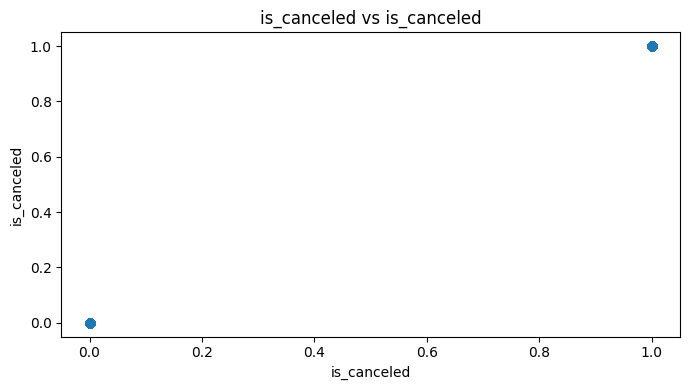

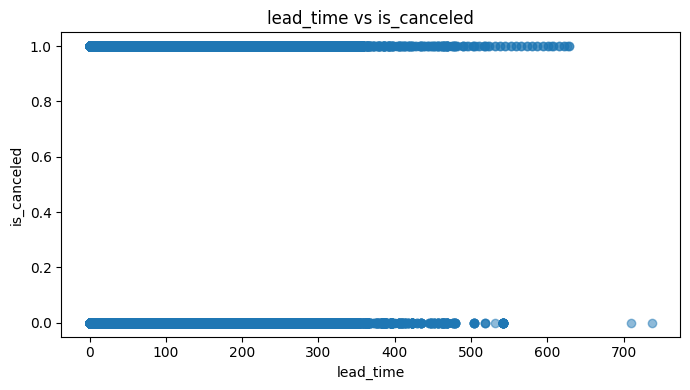

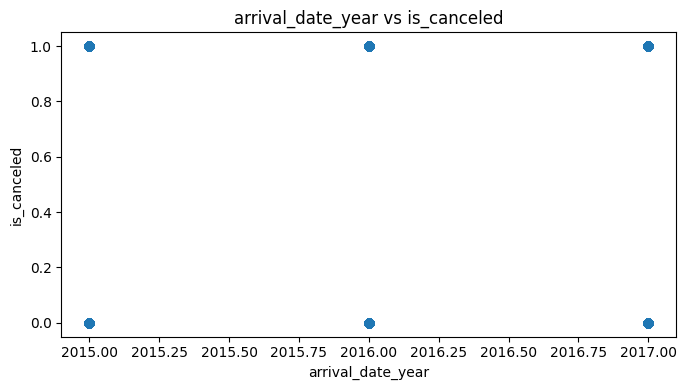

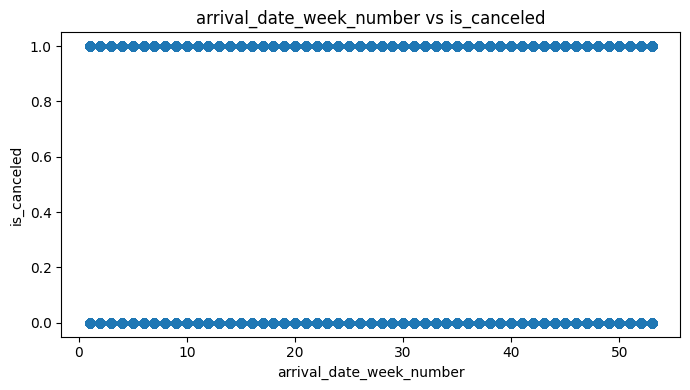

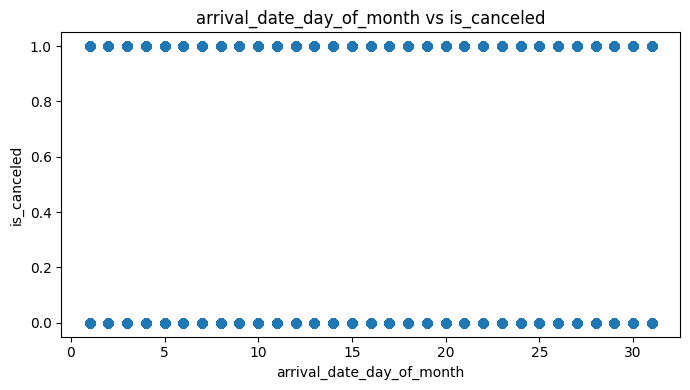

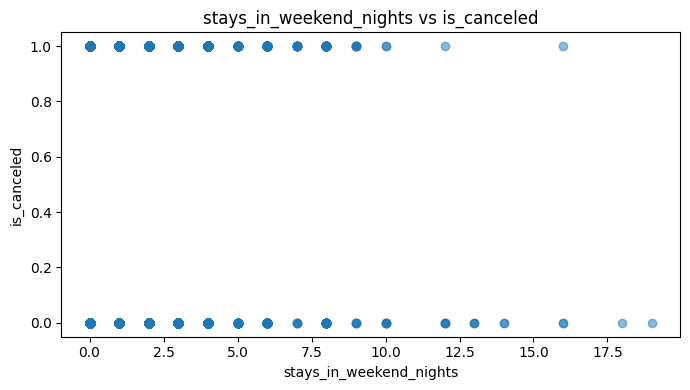

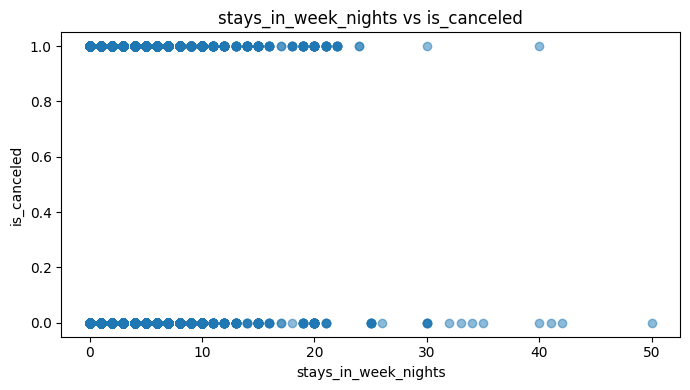

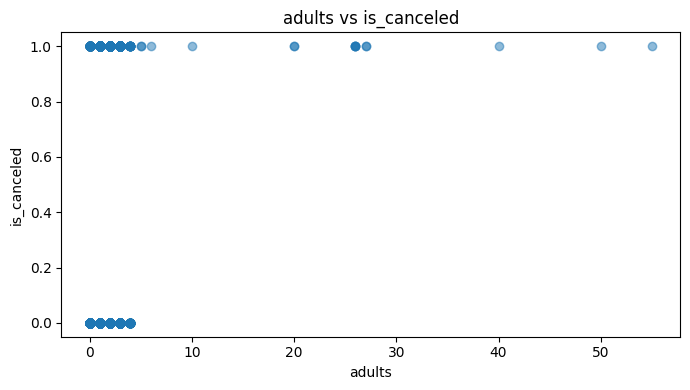

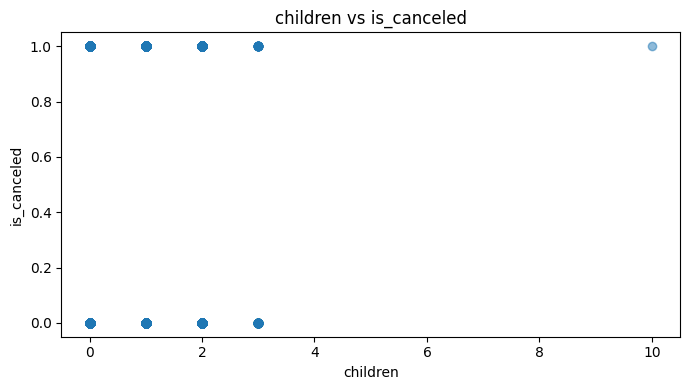

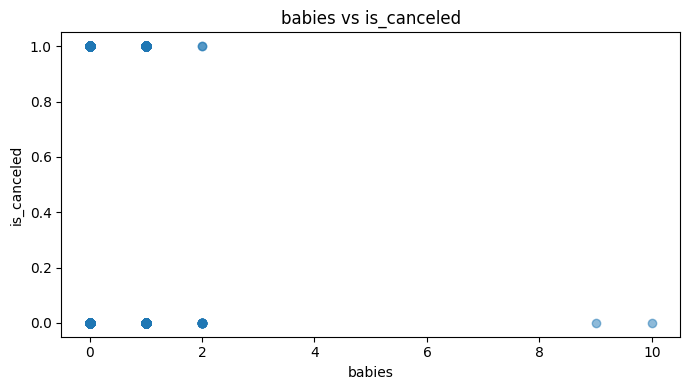

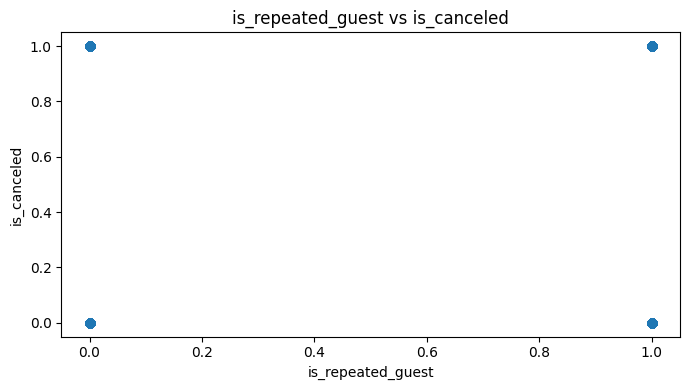

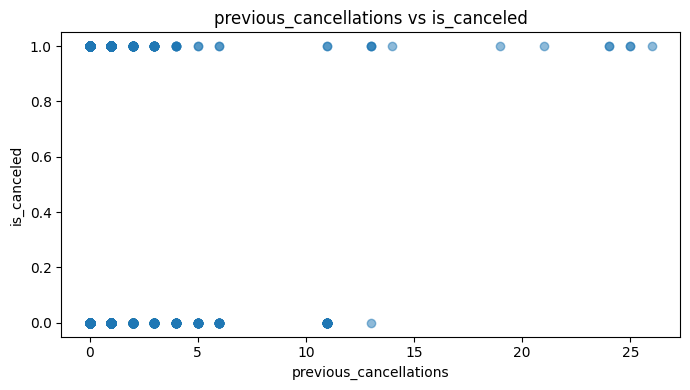

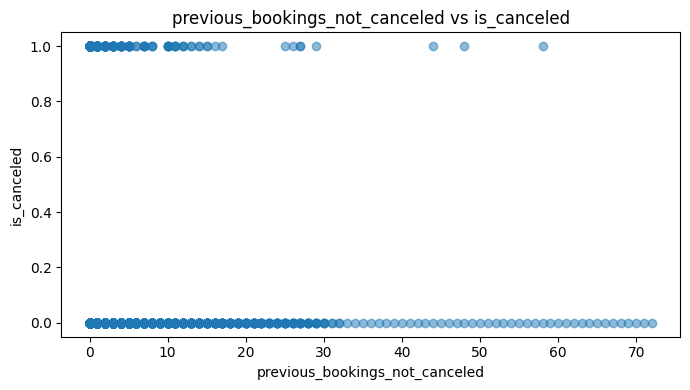

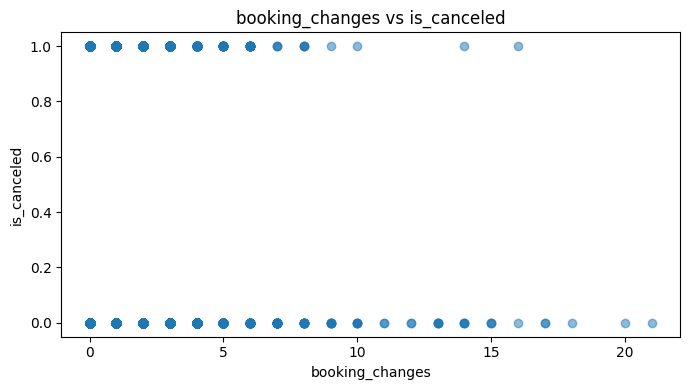

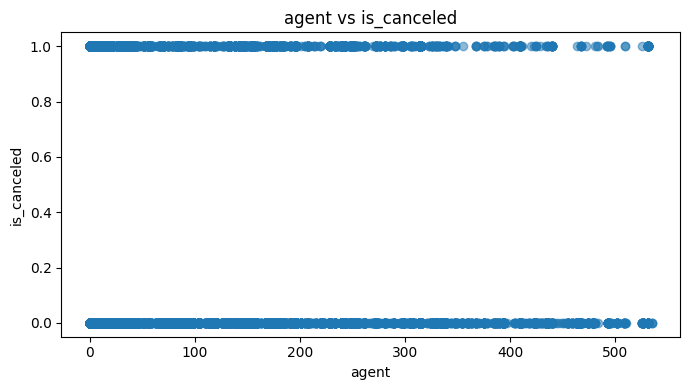

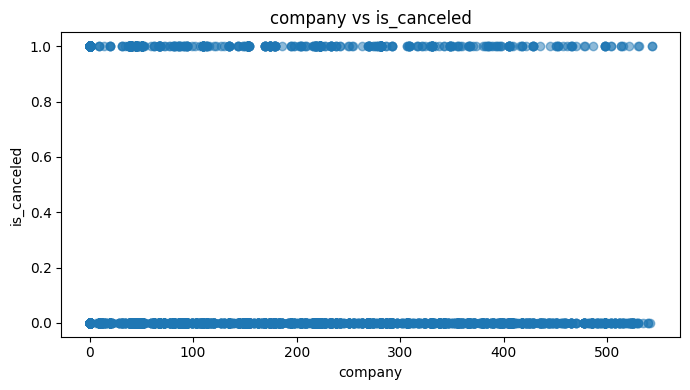

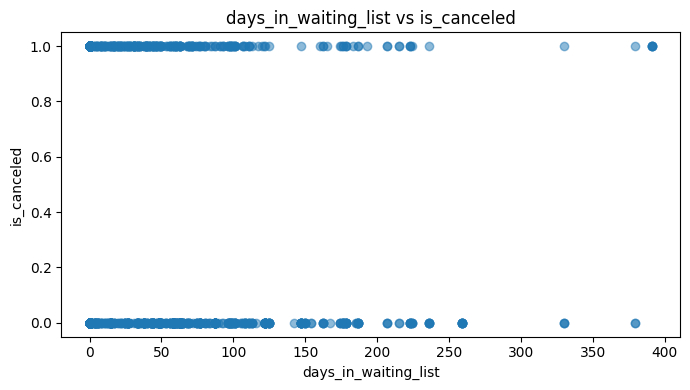

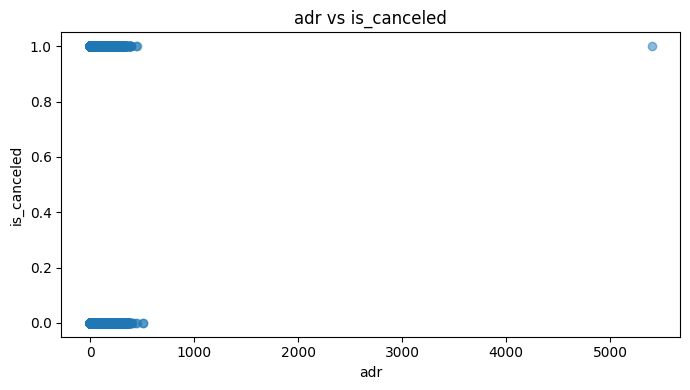

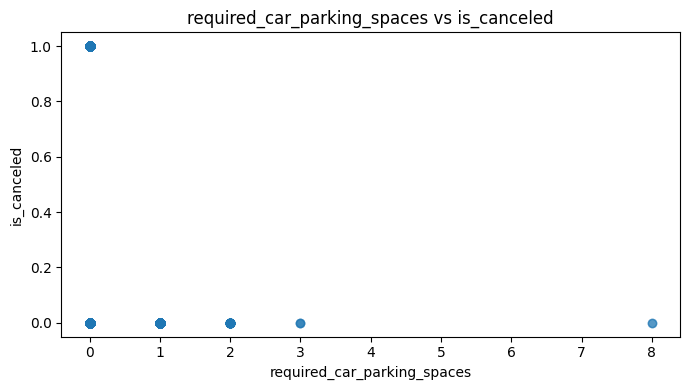

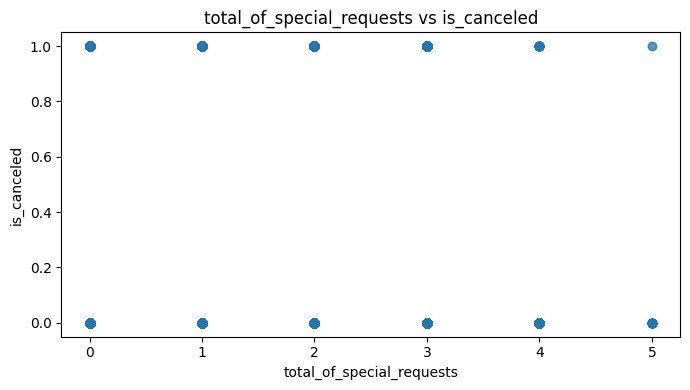

In [57]:
# Printing the scatter plots
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[col], df[target], alpha=0.5)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

#### **Correlation with Target**

In [58]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Calculate correlation with target
correlation_with_target = (
    df[numerical_cols]
    .corr()["is_canceled"]
    .sort_values(ascending=False)
)

display(correlation_with_target)

,is_canceled
is_canceled,1.000000
lead_time,0.184806
adr,0.127986
arrival_date_year,0.088030
stays_in_week_nights,0.082928
adults,0.081816
children,0.067369
stays_in_weekend_nights,0.060191
previous_cancellations,0.051468
arrival_date_day_of_month,0.005328


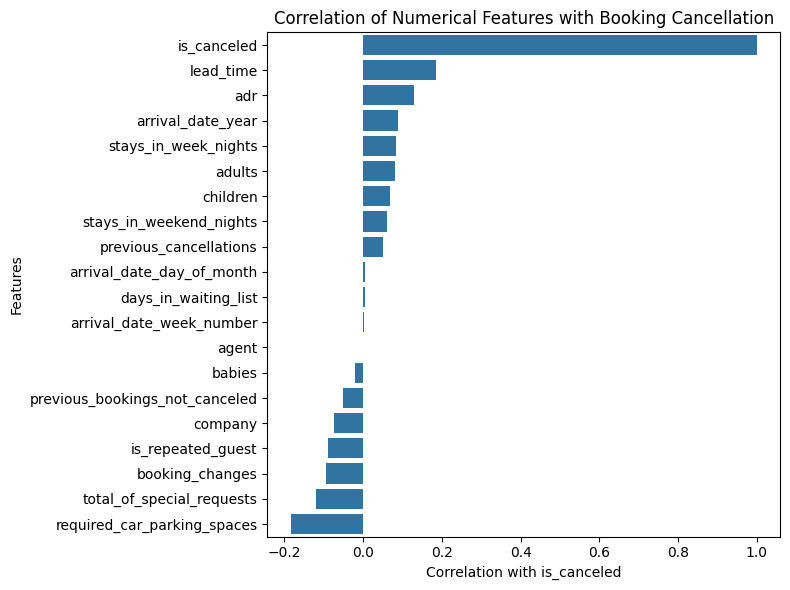

In [59]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=correlation_with_target.values,
    y=correlation_with_target.index
)

plt.title("Correlation of Numerical Features with Booking Cancellation")
plt.xlabel("Correlation with is_canceled")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

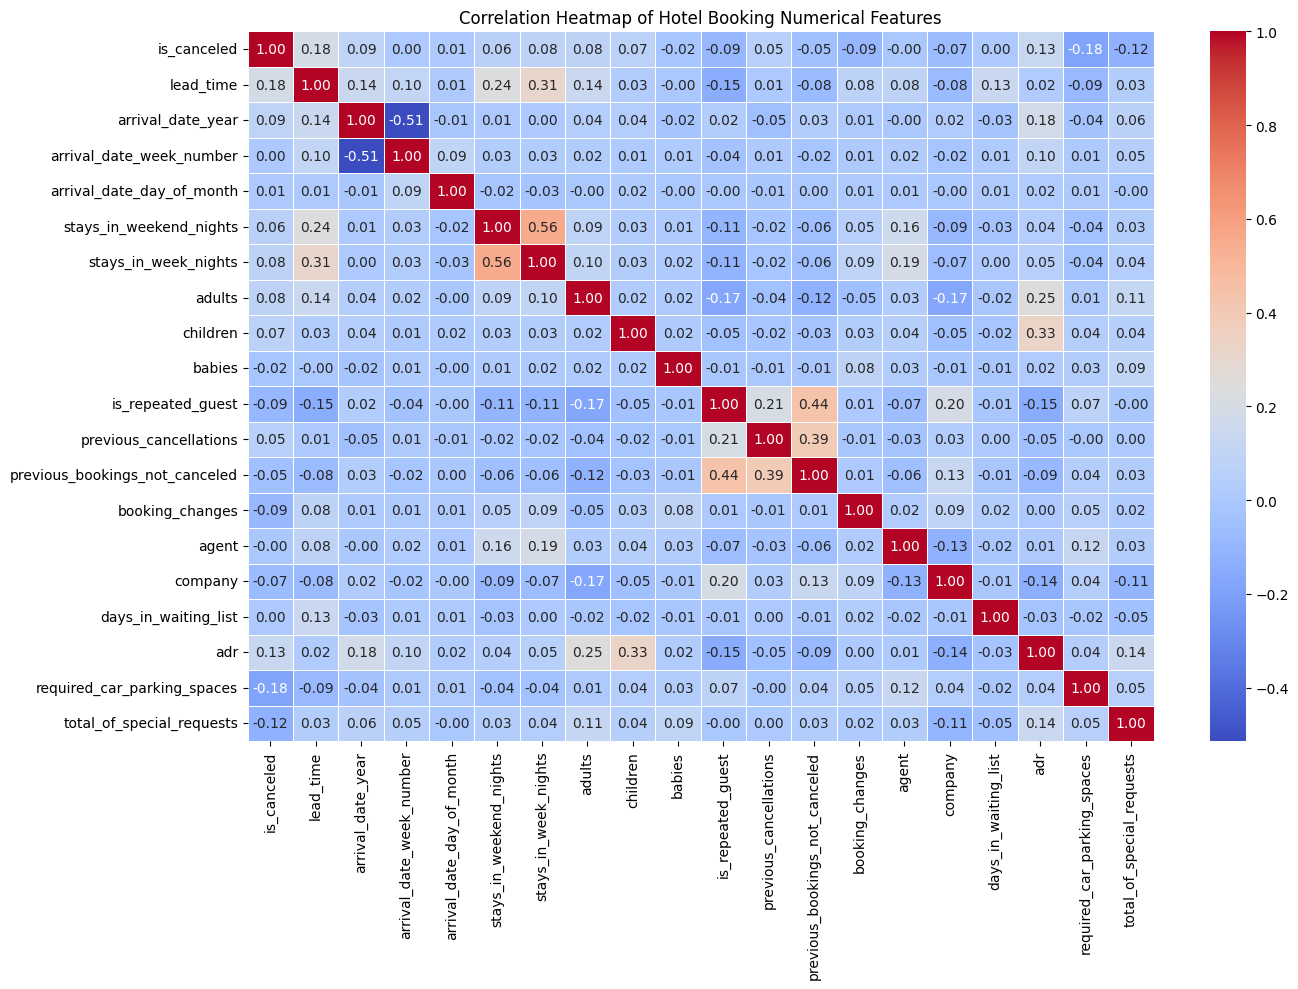

In [60]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Hotel Booking Numerical Features")
plt.tight_layout()
plt.show()

In [61]:
# Get the categorical column
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(categorical_cols)

['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


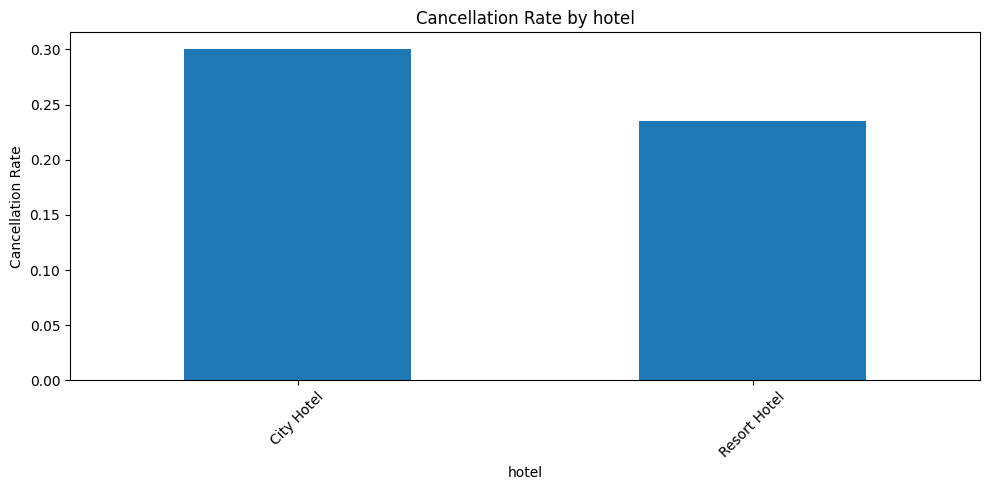

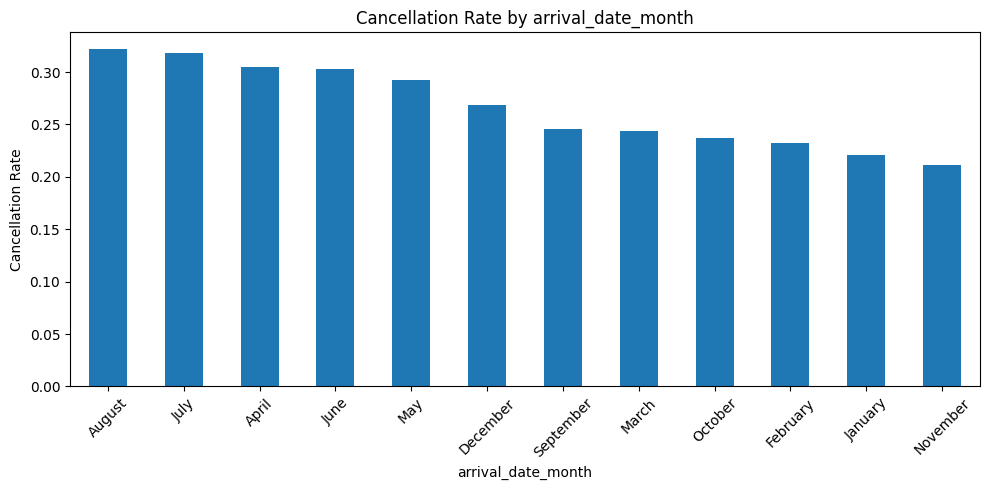

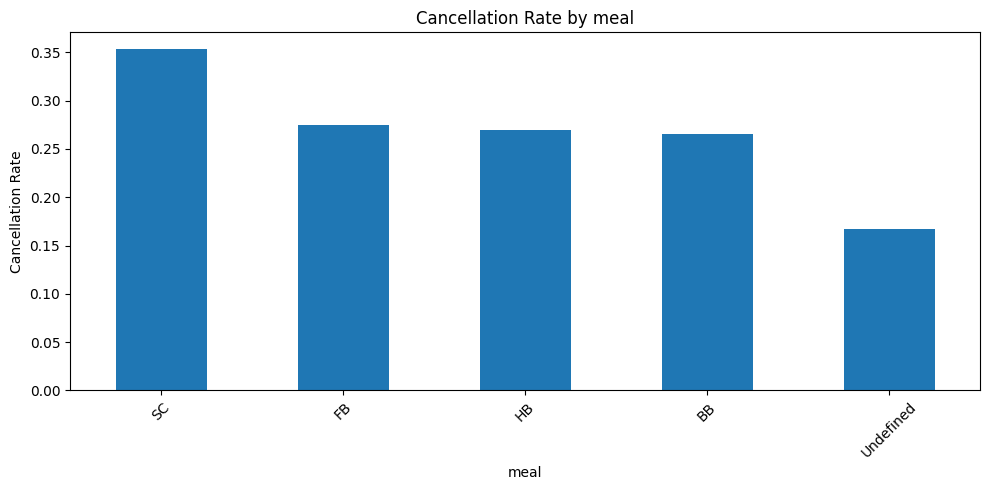

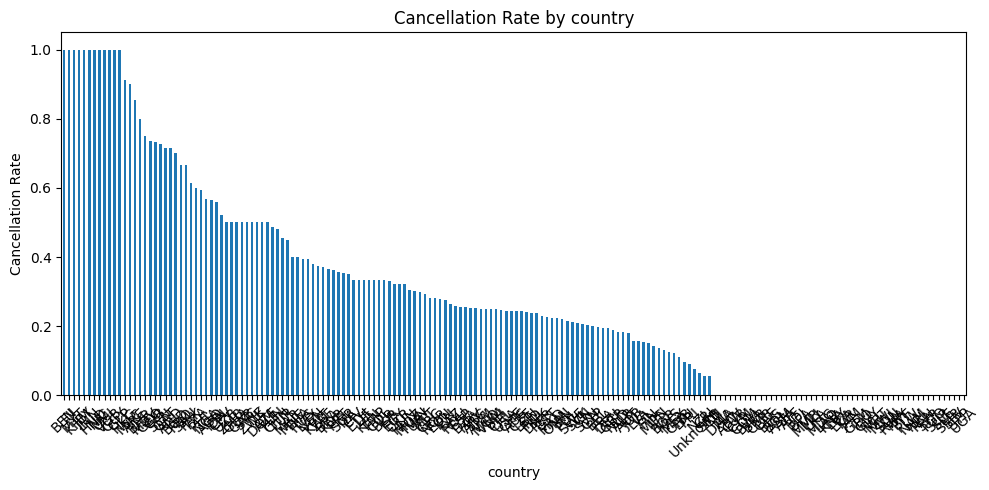

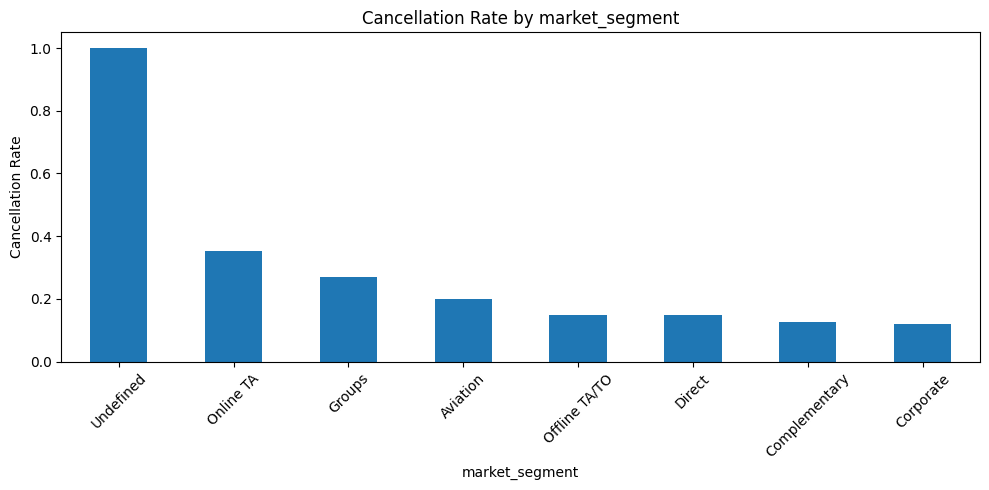

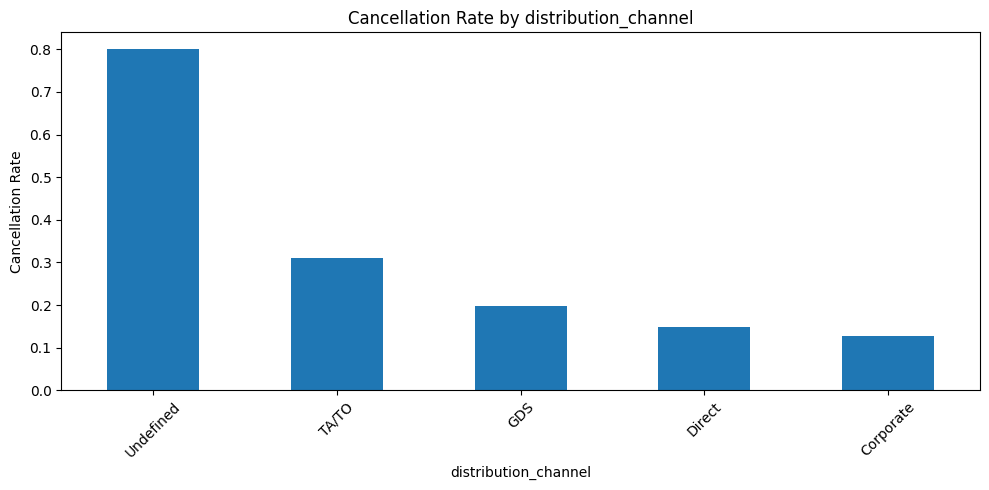

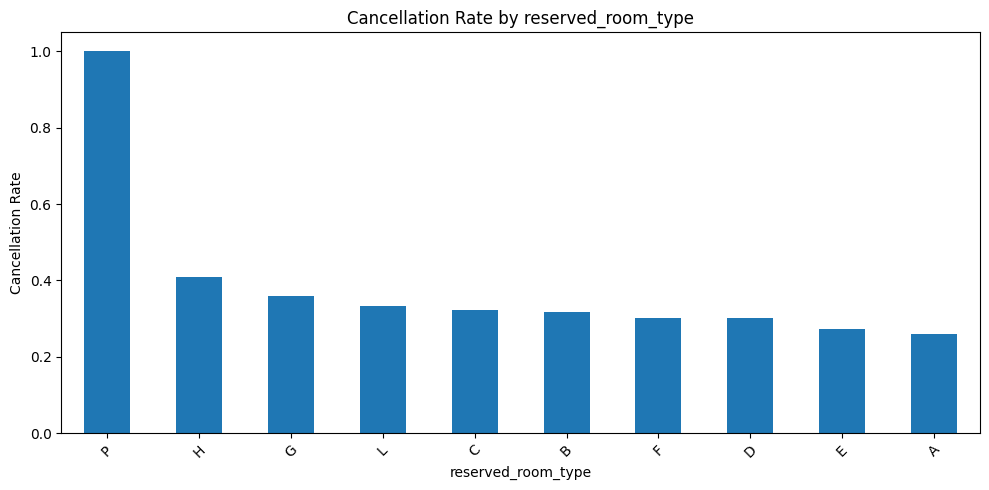

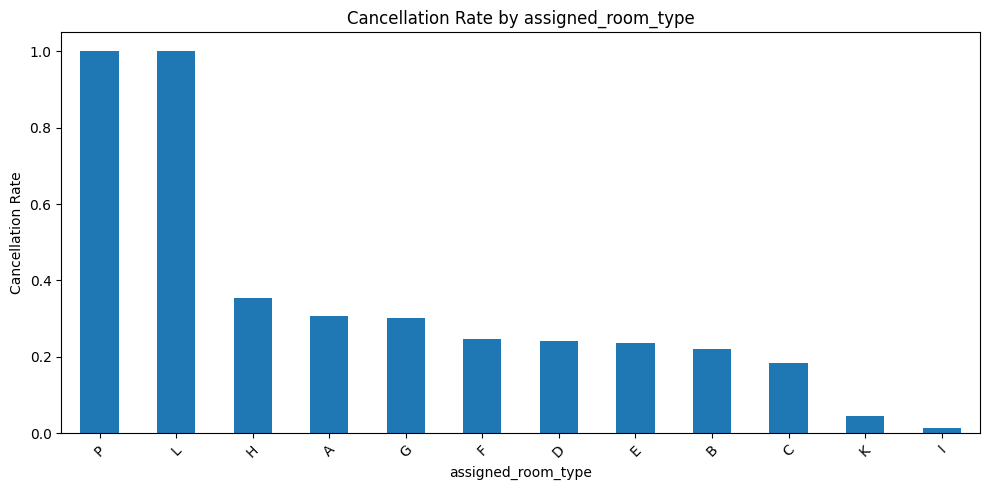

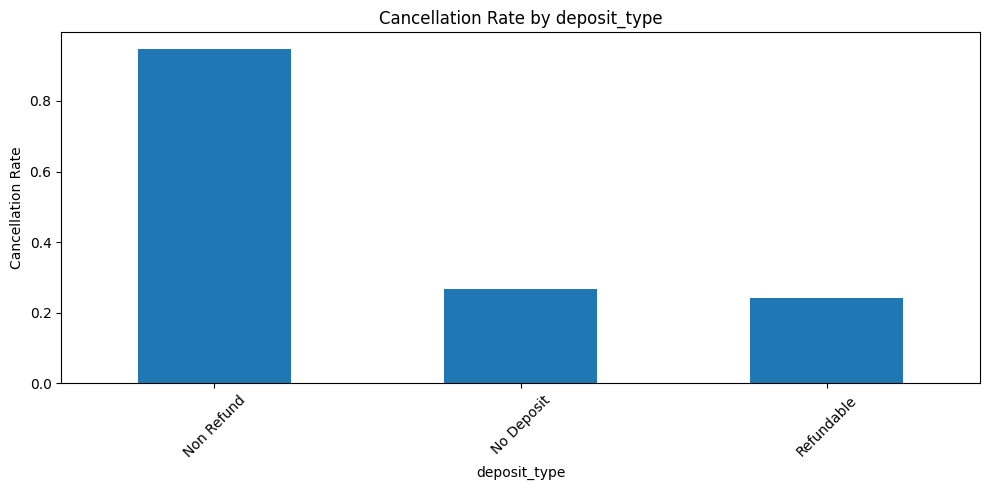

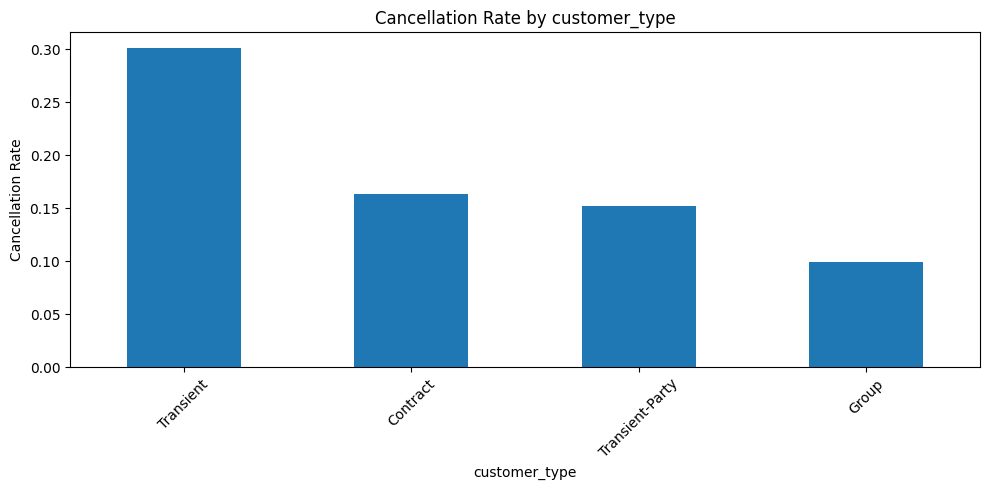

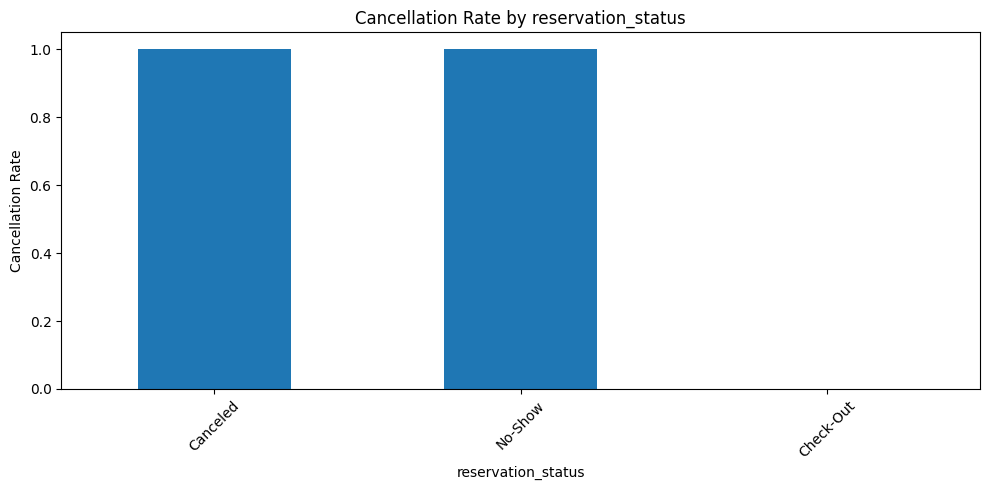

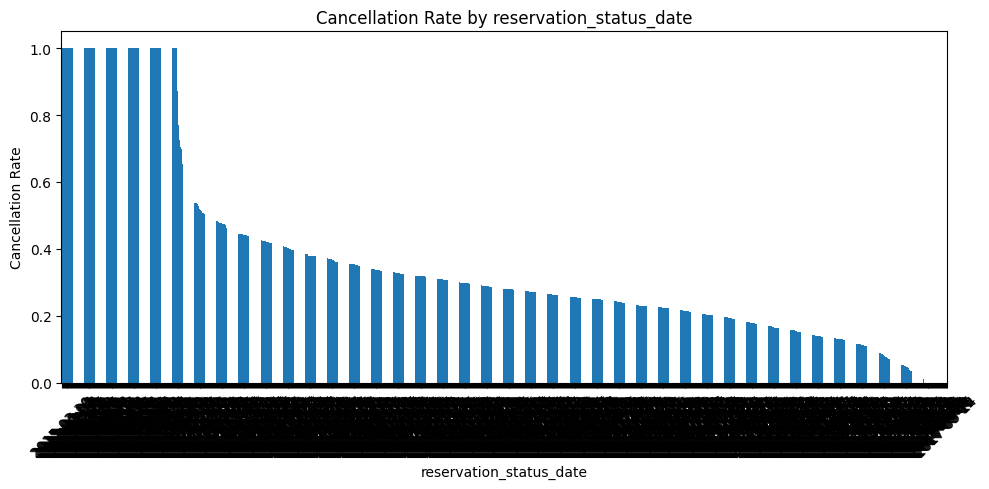

In [62]:
# Plotting the cancelation rate
for col in categorical_cols:
    cancellation_rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    cancellation_rate.plot(kind="bar")
    plt.title(f"Cancellation Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Cancellation Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

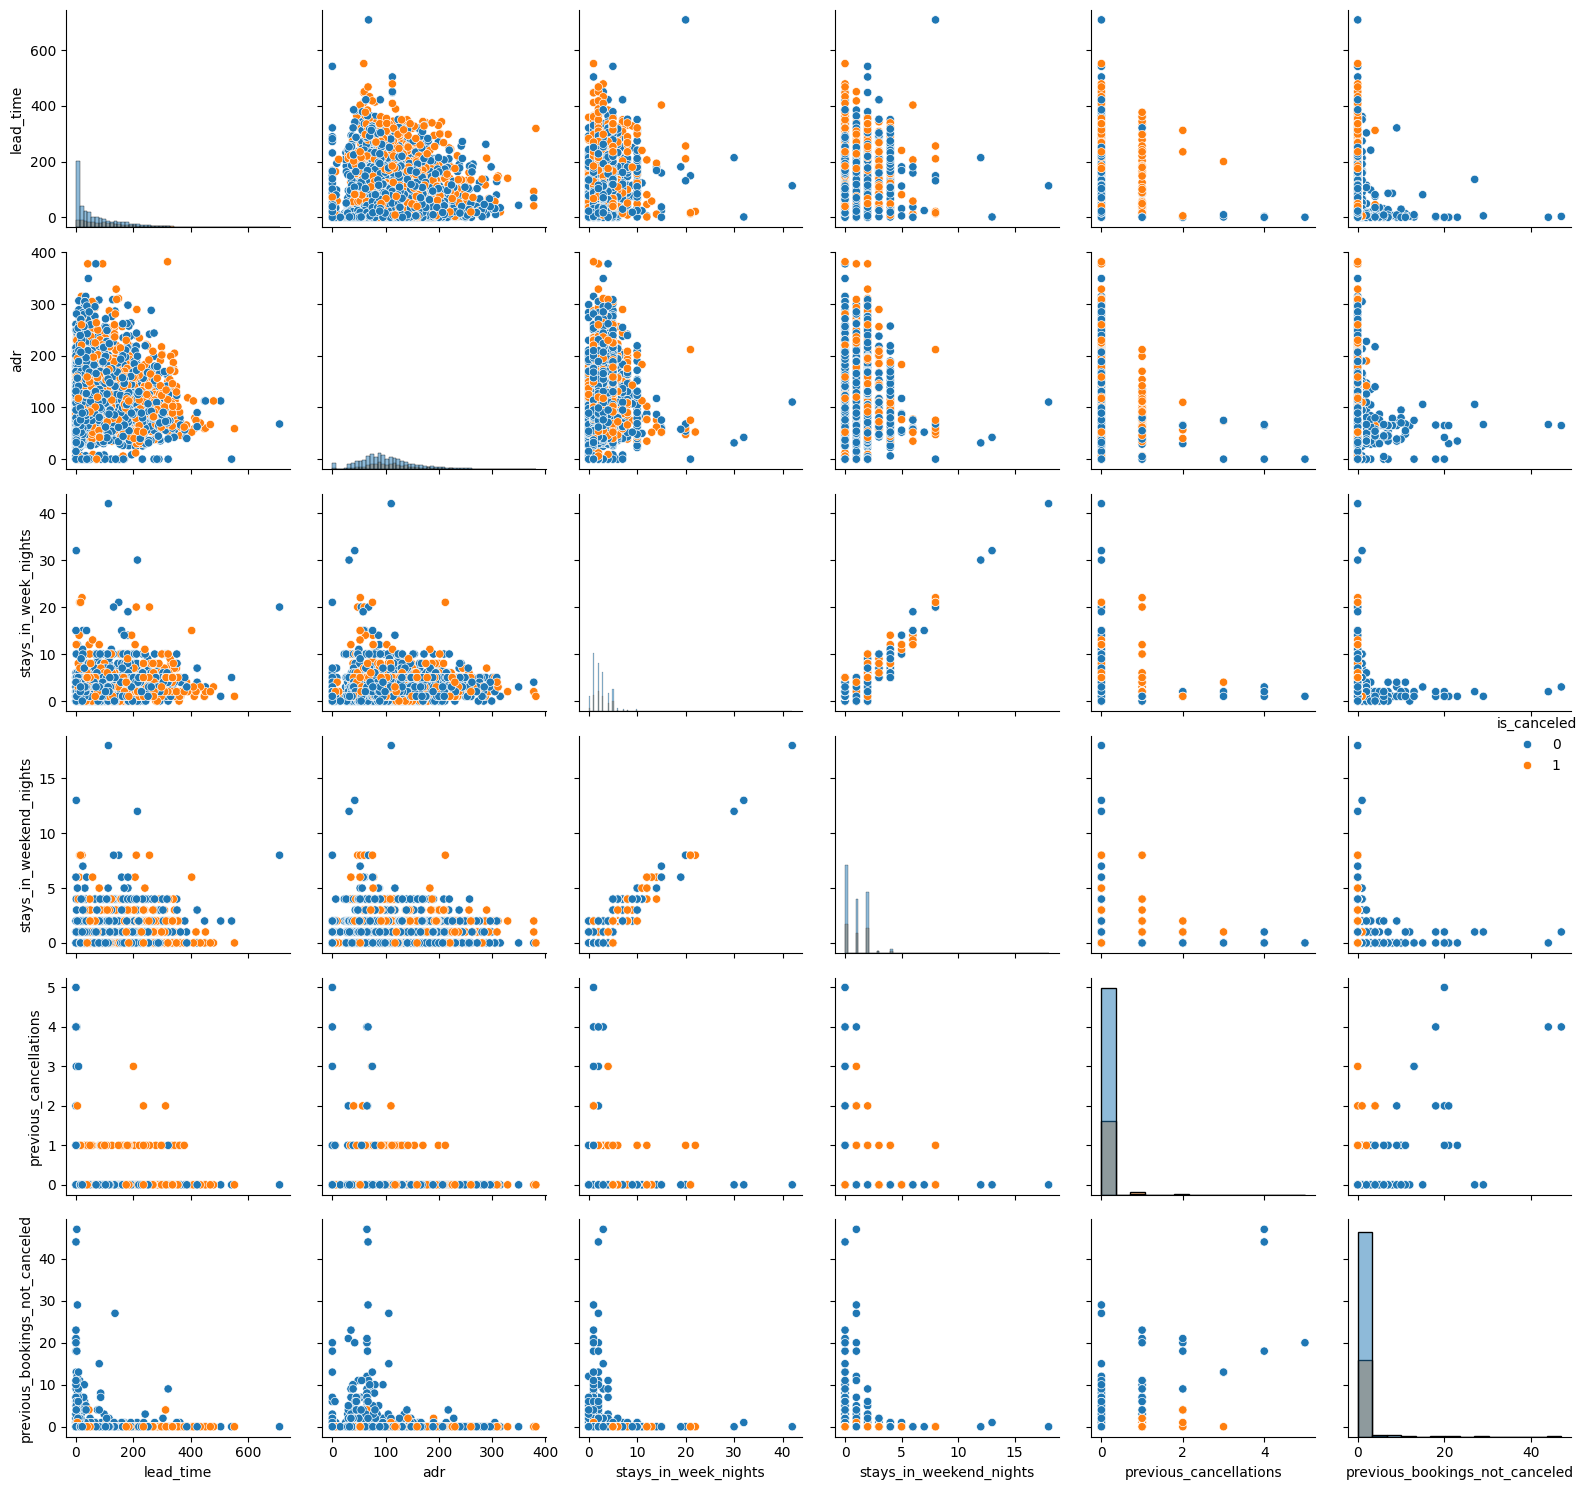

In [66]:
pairplot_features = [
    "is_canceled",
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

sns.pairplot(
    df[pairplot_features].sample(5000, random_state=42),
    hue="is_canceled",
    diag_kind="hist"
)
plt.tight_layout()
plt.show()

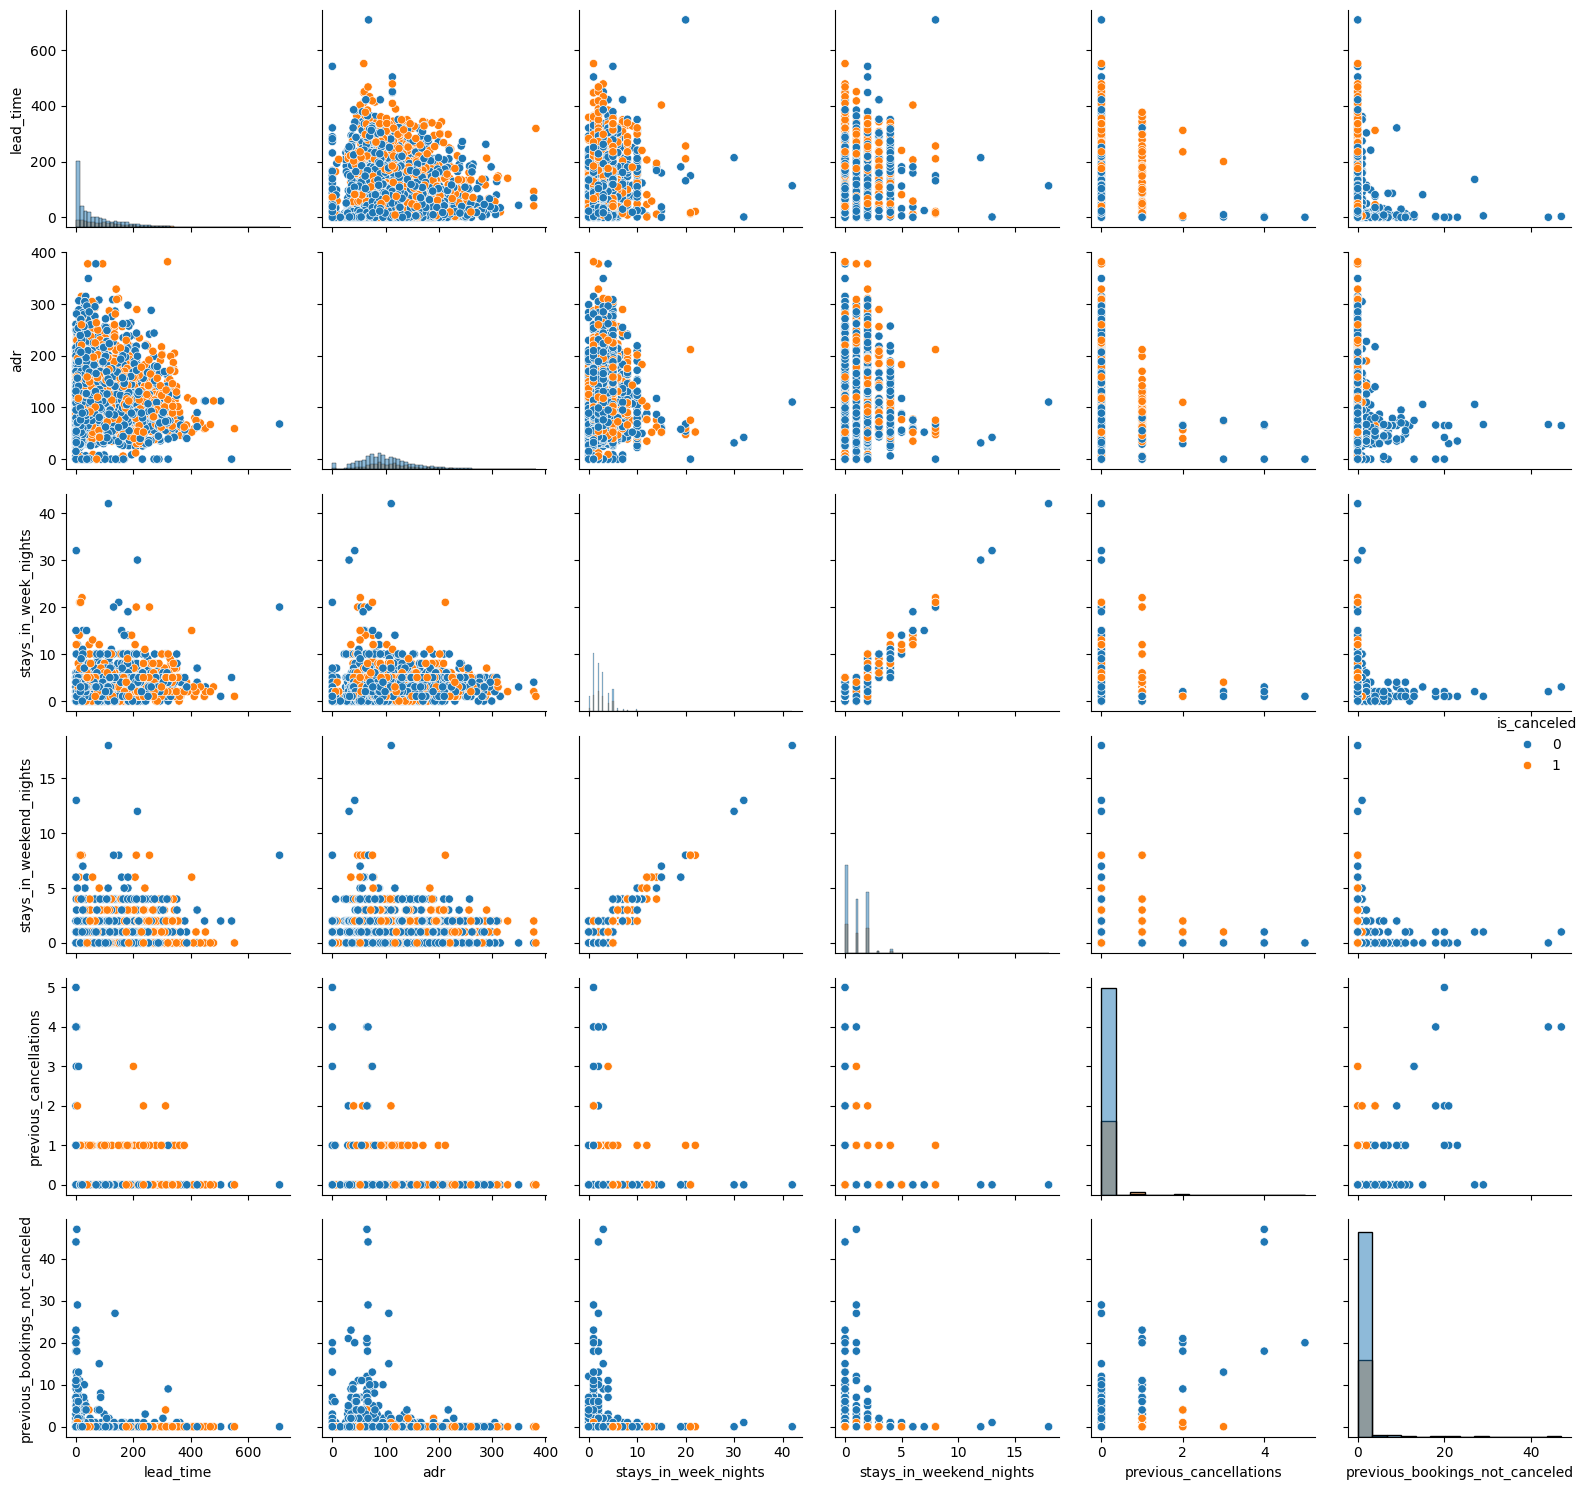

In [67]:
#pairplot
pairplot_features = [
    "is_canceled",
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

sns.pairplot(
    df[pairplot_features].sample(5000, random_state=42),
    hue="is_canceled",
    diag_kind="hist"
)
plt.tight_layout()
plt.show()

## **Outlier Detection**

In [68]:
# Identify the outlier
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [69]:
numerical_cols

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

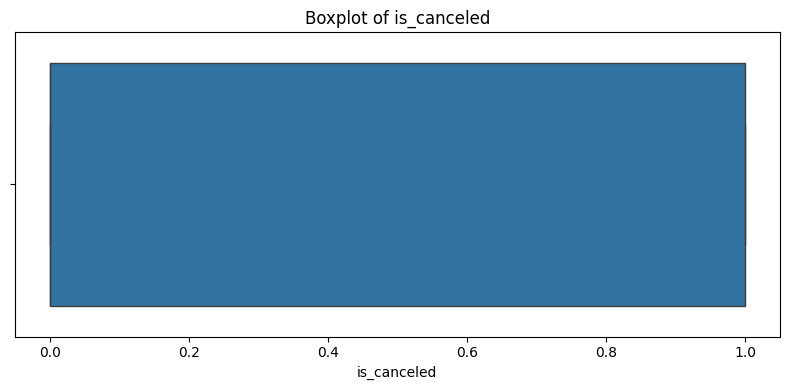

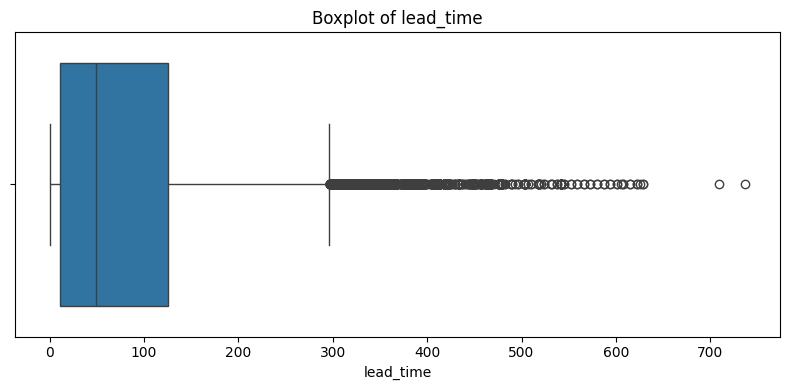

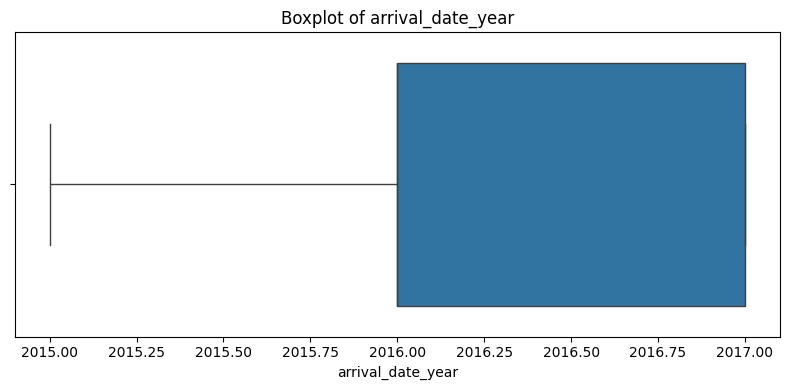

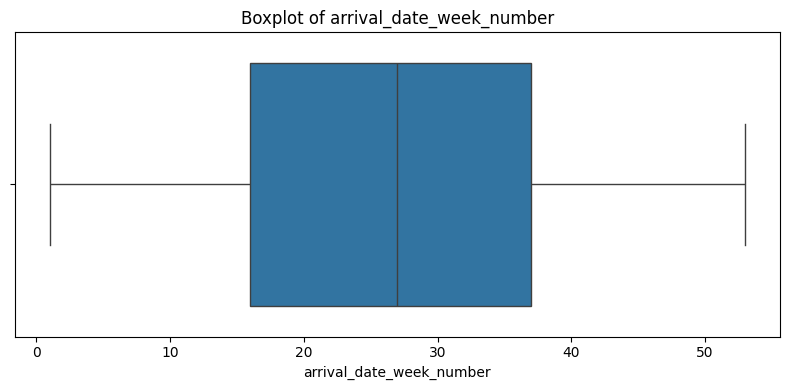

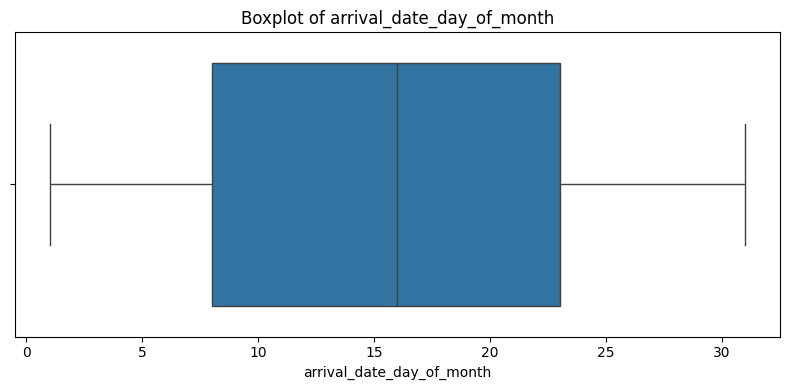

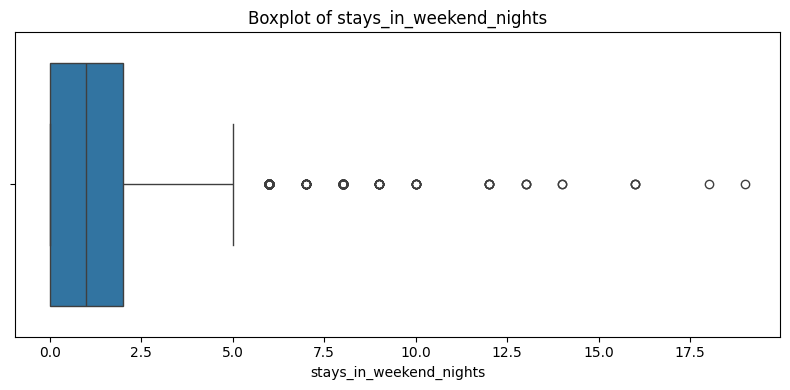

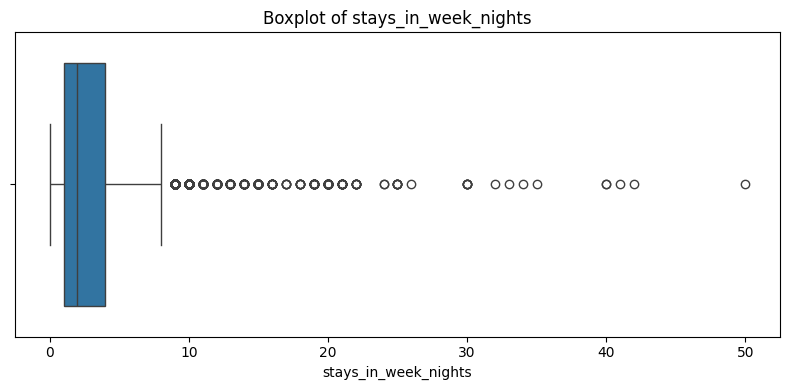

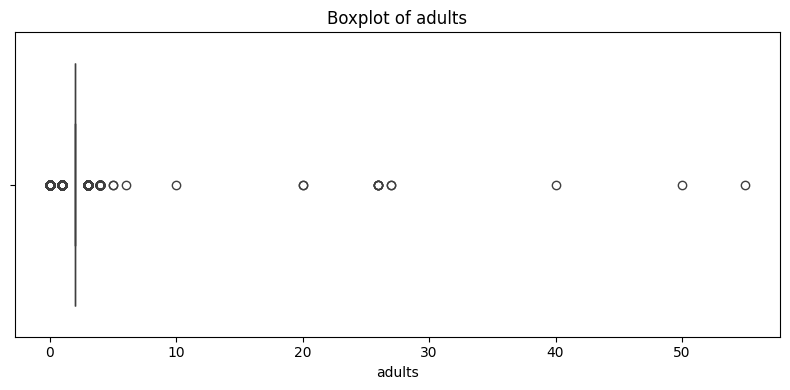

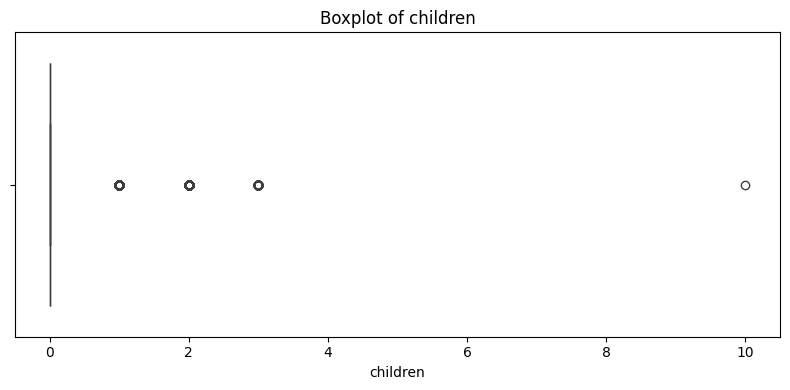

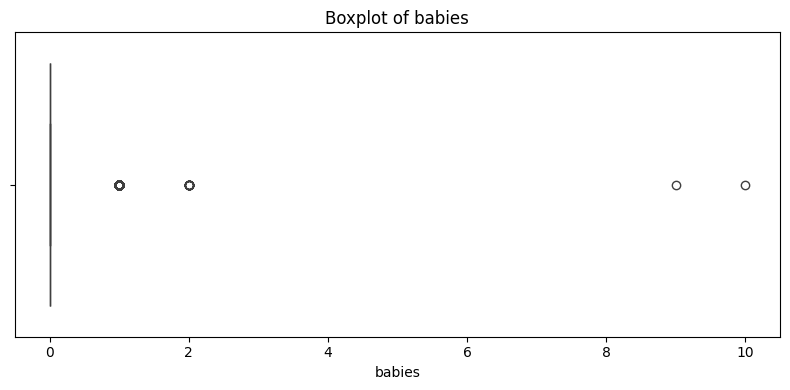

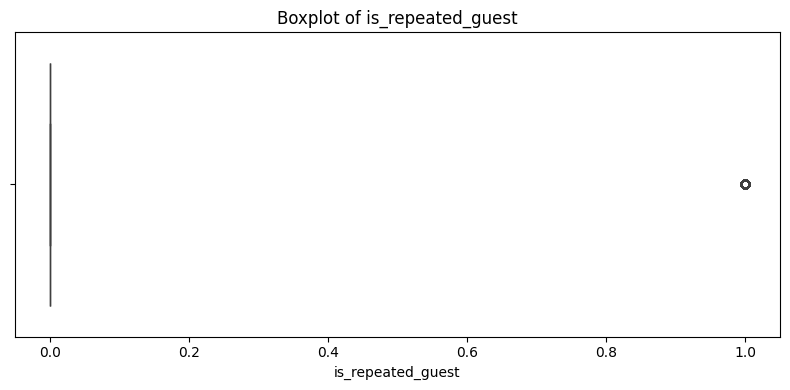

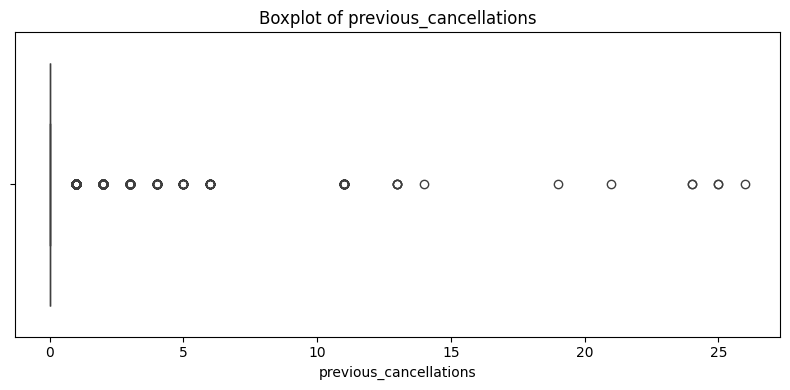

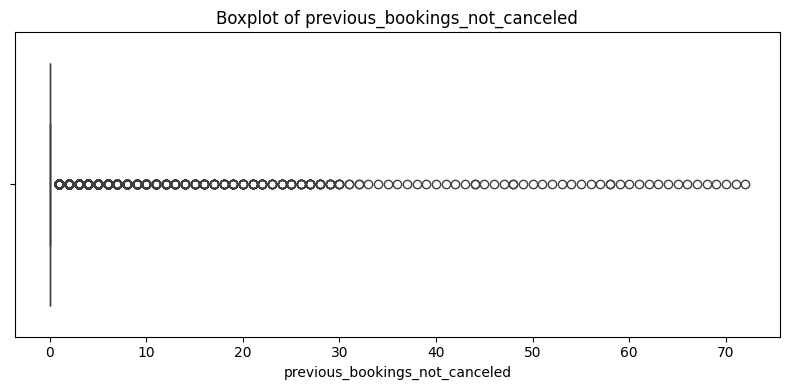

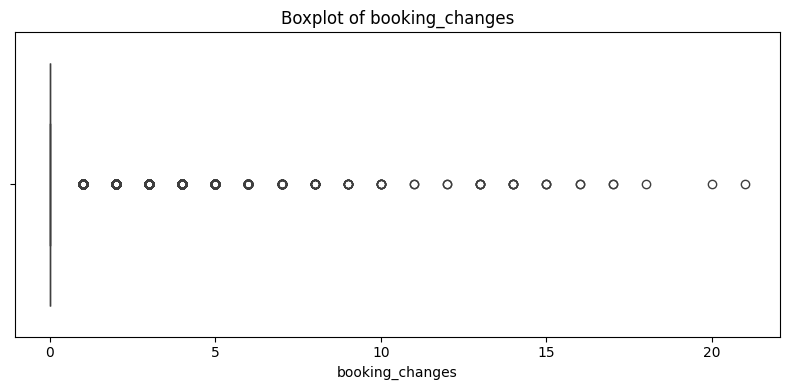

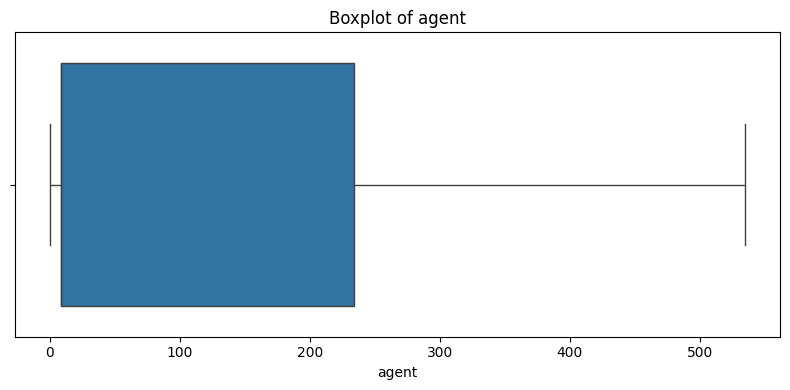

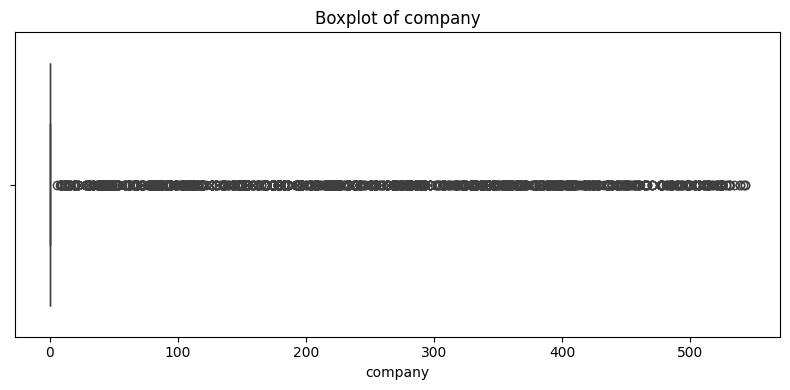

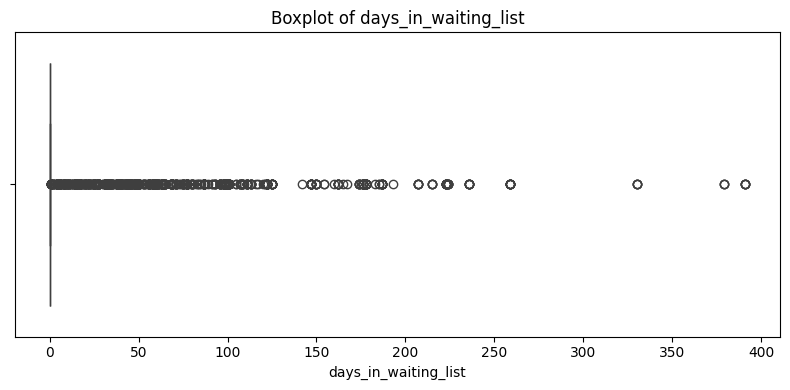

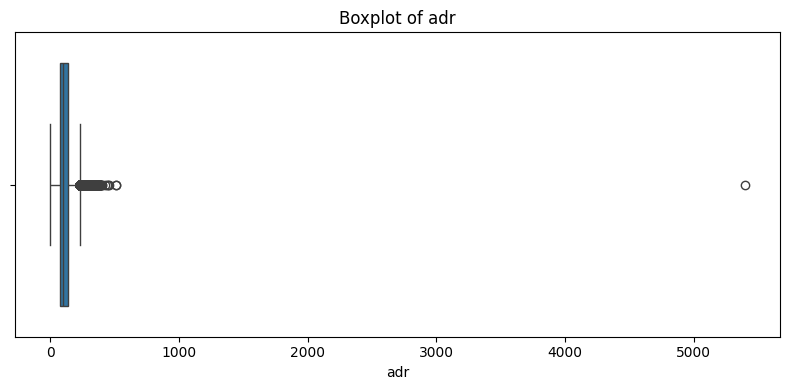

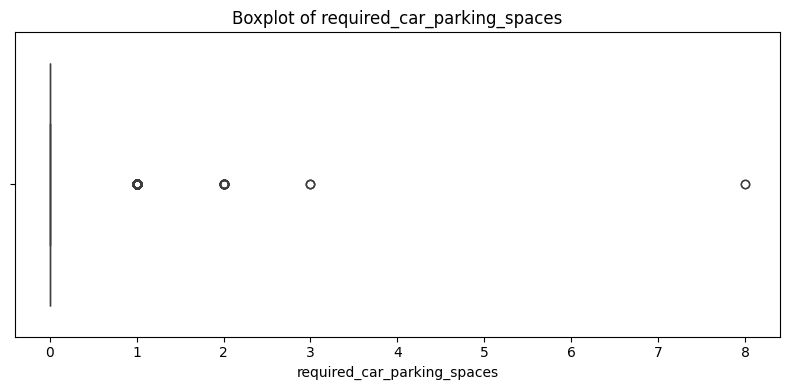

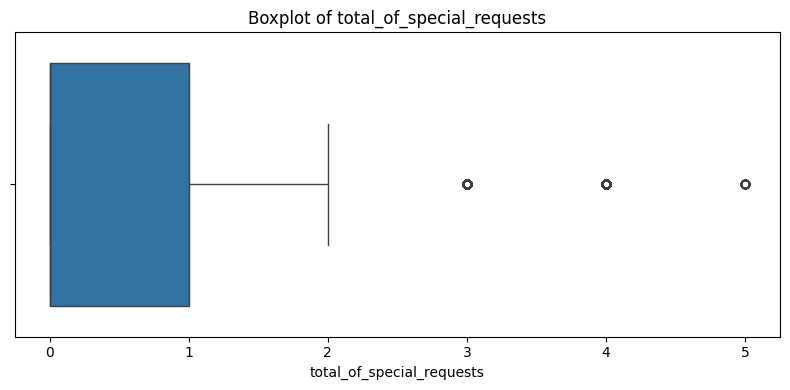

In [70]:
# Create the boxplot
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [71]:
# IQR - Interquartile range for the outliers
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[col] < Q1 - 1.5*IQR) |
                (df[col] > Q3 + 1.5*IQR)).sum()

    print(col, ":", outliers)

is_canceled : 0
lead_time : 2396
arrival_date_year : 0
arrival_date_week_number : 0
arrival_date_day_of_month : 0
stays_in_weekend_nights : 220
stays_in_week_nights : 1531
adults : 22899
children : 8364
babies : 914
is_repeated_guest : 3415
previous_cancellations : 1685
previous_bookings_not_canceled : 3545
booking_changes : 15902
agent : 0
company : 5259
days_in_waiting_list : 860
adr : 2490
required_car_parking_spaces : 7313
total_of_special_requests : 2673


In [73]:
# Cap Outliers
outlier_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

## **Feature Encoding**

In [96]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

In [103]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [98]:
encoded_data = encoder.fit_transform(df[categorical_cols])

In [99]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)

In [100]:
encoded_df

""
0
1
2
3
4
...
119385
119386
119387
119388


In [101]:
encoded_df.shape

(87396, 0)

### **TRAIN TEST SPLIT()**

In [83]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
X_train.shape

(69916, 1175)

In [86]:
X_test.shape

(17480, 1175)

### **Scaling**

In [89]:
scaler = StandardScaler()

In [90]:
scaler

StandardScaler()

In [91]:
X_train = scaler.fit_transform(X_train)

In [92]:
X_train

array([[ 2.68342084,  1.15144488, -0.05986653, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.90368612, -0.30712707, -1.81175589, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.92833977, -1.76569902,  1.18105509, ..., -0.00756405,
         0.        , -0.00378194],
       ...,
       [-0.6324959 ,  1.15144488, -1.30078816, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.96532026, -1.76569902,  0.3781058 , ..., -0.00756405,
         0.        , -0.00378194],
       [-0.96532026, -0.30712707, -1.59276972, ..., -0.00756405,
         0.        , -0.00378194]])

In [93]:
X_test = scaler.transform(X_test)

In [94]:
X_test

array([[-0.96532026, -1.76569902,  0.45110119, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.78041784, -0.30712707,  0.59709197, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.73111053, -0.30712707,  1.76501821, ..., -0.00756405,
         0.        , -0.00378194],
       ...,
       [-0.92833977,  1.15144488, -1.30078816, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.75576418, -0.30712707,  1.91100899, ..., -0.00756405,
         0.        , -0.00378194],
       [-0.96532026, -0.30712707, -1.30078816, ..., -0.00756405,
         0.        , -0.00378194]])

In [105]:
# Column Transformer
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [106]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [110]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [111]:
## Create the column transformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [112]:
X_train_processed = preprocessor.fit_transform(X_train)

In [113]:
X_test_processed = preprocessor.transform(X_test)

In [116]:
X_test_processed.shape

(17480, 19)

In [117]:
X_train_processed.shape

(69916, 19)